# Preprocessing of heart cell altas, single donor

In [1]:
library(Signac)
library(Seurat)
library(GenomicRanges)
library(data.table)

library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)

library(GenomeInfoDb)
library(IRanges)
library(rtracklayer)
library(ggplot2)
library(dplyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    uns

## Preprocessing with Signac:
https://stuartlab.org/signac/articles/pbmc_multiomic

In [ ]:
sample_to_use <- "HCAHeartST11350194_HCAHeartST11445771"
out_dir <- "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data"
heart_cell_atlas = readRDS(file.path(out_dir, paste0(sample_to_use, ".rds")))

# QUALITY CONTROL PER CELL

-  DNA accessability -> remove outliers
- unusual low count for RNA/ATAC assay
- unusual high count for RNA/ATAC assay

### Transcription Start Site Enrichment: 0:positive values

- relative abundance of signal close to TSS compared to background = genomic region
- inside into: transcription activity and regulatory elements near the TSS
- high TSS enrichment -> active transcription, potential regulatory element (if TSS<1, remove cell)

### Nucleosome Signal
- density or occupancy of nucleosomes along the genome: info about accessibility
- high signal indicates higher density of nucleosomes (less accessible)
- only keep cells with low score (more accessible)

## RNA Assay first

In [3]:
str(heart_cell_atlas, max.level = 3)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 2
  .. ..$ RNA  :Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. ..$ Peaks:Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  ..@ meta.data   :'data.frame':	8663 obs. of  65 variables:
  .. ..$ orig.ident                 : Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..$ nCount_RNA                 : num [1:8663] 43638 43415 43052 42859 41263 ...
  .. ..$ nFeature_RNA               : int [1:8663] 7264 7322 7285 7215 7131 7124 7247 6741 7867 7376 ...
  .. ..$ sangerID                   : chr [1:8663] "HCAHeartST11350194" "HCAHeartST11350194" "HCAHeartST11350194" "HCAHeartST11350194" ...
  .. ..$ combinedID                 : chr [1:8663] "HCAHeartST11350194_HCAHeartST11445771" "HCAHeartST11350194_HCAHeartST11445771" "HCAHeartST11350194_HCAHeartST11445771" "HCAHeartST11350194_HCAHeartST11445771" ...
  .. ..$ donor                      : chr [1:8663] "A61

In [5]:
head(heart_cell_atlas@meta.data[c("pct_counts_mt", "total_counts_mt", "total_counts")])

,pct_counts_mt,total_counts_mt,total_counts
,<dbl>,<dbl>,<dbl>
ACCACATAGGGCTAAA-1,0.03381272,15,44362
ACATTAGTCCTAGTAA-1,3.92981360,1729,43997
TCGGTTCTCGGGACCT-1,0.04115697,18,43735
AGACTATGTAACCAGC-1,0.02749771,12,43640
ATTATCCTCGCACACA-1,0.03092808,13,42033
CGCACACAGGTTACAC-1,0.09346024,38,40659


In [6]:
summary(heart_cell_atlas@meta.data[c("pct_counts_mt", "total_counts_mt", "total_counts")])

 pct_counts_mt     total_counts_mt    total_counts  
 Min.   :0.00000   Min.   :   0.00   Min.   :  500  
 1st Qu.:0.05015   1st Qu.:   3.00   1st Qu.: 1387  
 Median :0.15848   Median :   6.00   Median : 3704  
 Mean   :0.55546   Mean   :  16.99   Mean   : 5191  
 3rd Qu.:0.62252   3rd Qu.:  15.00   3rd Qu.: 7233  
 Max.   :4.99076   Max.   :1729.00   Max.   :44362  

In [3]:
heart_cell_atlas@meta.data["percent.mt"] <- heart_cell_atlas@meta.data["pct_counts_mt"]

In [11]:
healthy_breast <- readRDS("/nfs/data3/mopitas/mapra/multiome_data/diverse_ancestry_2024/KTB_pool-4-Ashkenazi_jew/rds_files/healthy_breast_peaks_called.rds")

In [14]:
str(healthy_breast, max.level = 3)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 3
  .. ..$ RNA  :Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. ..$ ATAC :Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  .. ..$ peaks:Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  ..@ meta.data   :'data.frame':	6913 obs. of  12 variables:
  .. ..$ orig.ident           : Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..$ nCount_RNA           : num [1:6913] 10094 354 777 1119 369 ...
  .. ..$ nFeature_RNA         : int [1:6913] 4337 321 621 854 315 3702 2741 214 2218 571 ...
  .. ..$ nCount_ATAC          : num [1:6913] 26820 1405 10806 10466 2414 ...
  .. ..$ nFeature_ATAC        : int [1:6913] 11808 751 5225 5073 1259 6024 5450 1670 3719 361 ...
  .. ..$ percent.mt           : num [1:6913] 0.0297 0.2825 1.4157 0.0894 0 ...
  .. ..$ nucleosome_signal    : num [1:6913] 0.765 0.677 1.013 0.787 0.486 ...
  .. ..$ nucleosome_percentil

In [21]:
colnames(heart_cell_atlas@meta.data)

[1] "orig.ident"                  "nCount_RNA"                 
 [3] "nFeature_RNA"                "sangerID"                   
 [5] "combinedID"                  "donor"                      
 [7] "donor_type"                  "region"                     
 [9] "region_finest"               "age"                        
[11] "gender"                      "facility"                   
[13] "cell_or_nuclei"              "modality"                   
[15] "kit_10x"                     "flushed"                    
[17] "n_genes"                     "n_genes_by_counts"          
[19] "total_counts"                "total_counts_mt"            
[21] "pct_counts_mt"               "total_counts_ribo"          
[23] "pct_counts_ribo"             "scrublet_score"             
[25] "scrublet_leiden"             "cluster_scrublet_score"     
[27] "doublet_pval"                "doublet_bh_pval"            
[29] "batch_key"                   "leiden_scVI"                
[31] "cell_type"                   "cell_state_HCAv1"           
[33] "cell_state_scNym"            "cell_state_scNym_confidence"
[35] "cell_state"                  "latent_RT_efficiency"       
[37] "latent_cell_probability"     "latent_scale"               
[39] "n_counts"                    "_scvi_batch"                
[41] "_scvi_labels"                "clus20"                     
[43] "doublet_cls"                 "original_or_new"            
[45] "batch"                       "scANVI_predictions"         
[47] "leiden_scArches"             "peak_sangerID"              
[49] "peak_combinedID"             "peak_donor"                 
[51] "peak_donor_type"             "peak_region"                
[53] "peak_region_finest"          "peak_age"                   
[55] "peak_gender"                 "peak_facility"              
[57] "peak_cell_or_nuclei"         "peak_modality"              
[59] "peak_kit_10x"                "peak_flushed"               
[61] "peak_batch_key"              "peak_cell_type"             
[63] "peak_cell_state"             "nCount_Peaks"               
[65] "nFeature_Peaks"              "percent_mt"                 
[67] "percent.mt"

In [4]:
# change plot size, make wider
options(repr.plot.width=15, repr.plot.height=10)

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


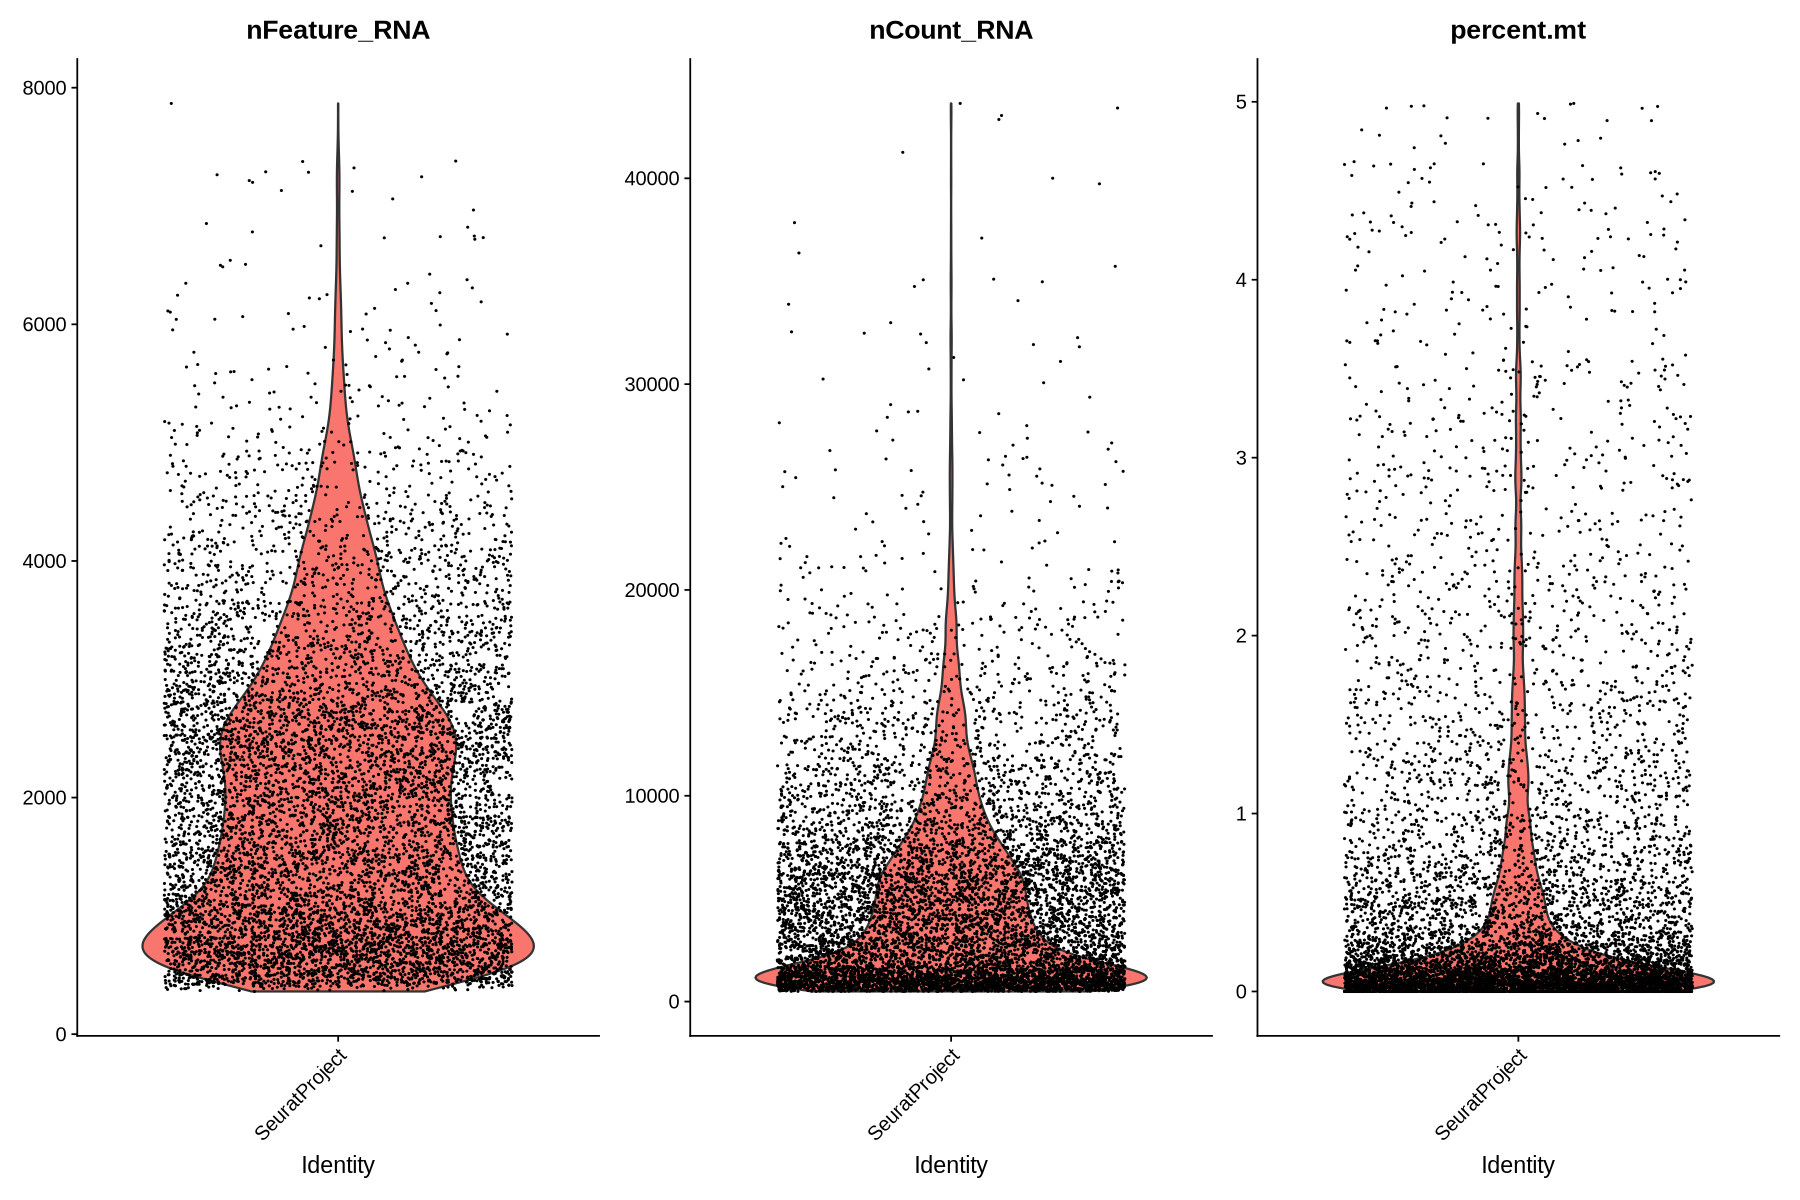

In [5]:
VlnPlot(heart_cell_atlas, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

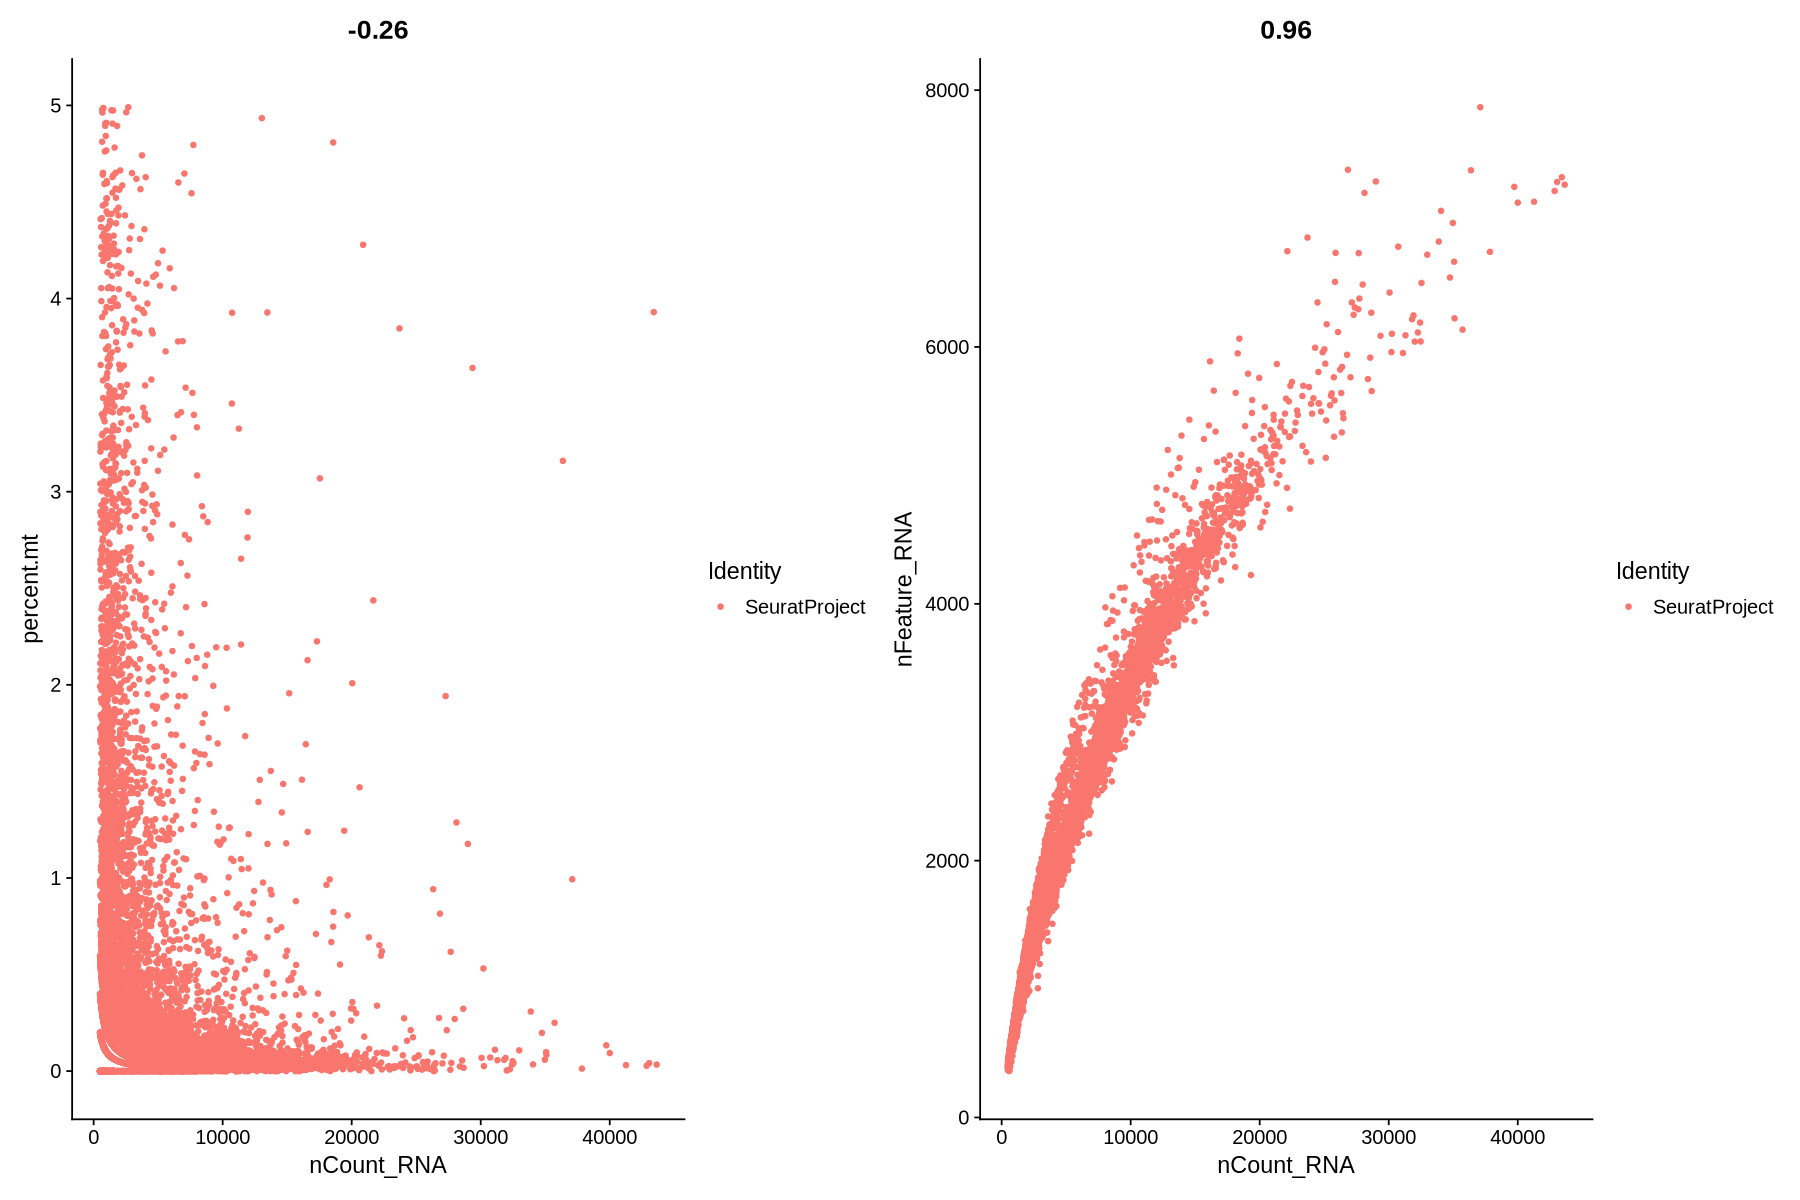

In [6]:
plot1 <- FeatureScatter(heart_cell_atlas, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(heart_cell_atlas, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

In [7]:
countLOW=quantile(heart_cell_atlas$nCount_RNA, prob=c(0.01))  
countHIGH=quantile(heart_cell_atlas$nCount_RNA, prob=0.99) 
featureLOW=quantile(heart_cell_atlas$nFeature_RNA, prob=0.01)
featureHIGH=quantile(heart_cell_atlas$nFeature_RNA, prob=0.99)

In [8]:
countLOW
countHIGH
featureLOW
featureHIGH

1% 
531

99% 
22821.7

1% 
422

99% 
5550.18

In [ ]:
# 1. Filter Cells by #features and %mt

# filter cells that have unique feature counts over 7000 (doublets) or less than 200 (low quality)
# filter cells that have >5% mitochondrial counts (low quality, dying)

heart_cell_atlas <- subset(heart_cell_atlas, subset = nFeature_RNA > 300 & nFeature_RNA < 7000 & percent.mt < 5)

In [10]:
heart_cell_atlas

An object of class Seurat 
462560 features across 8635 samples within 2 assays 
Active assay: RNA (32732 features, 0 variable features)
 1 layer present: counts
 1 other assay present: Peaks

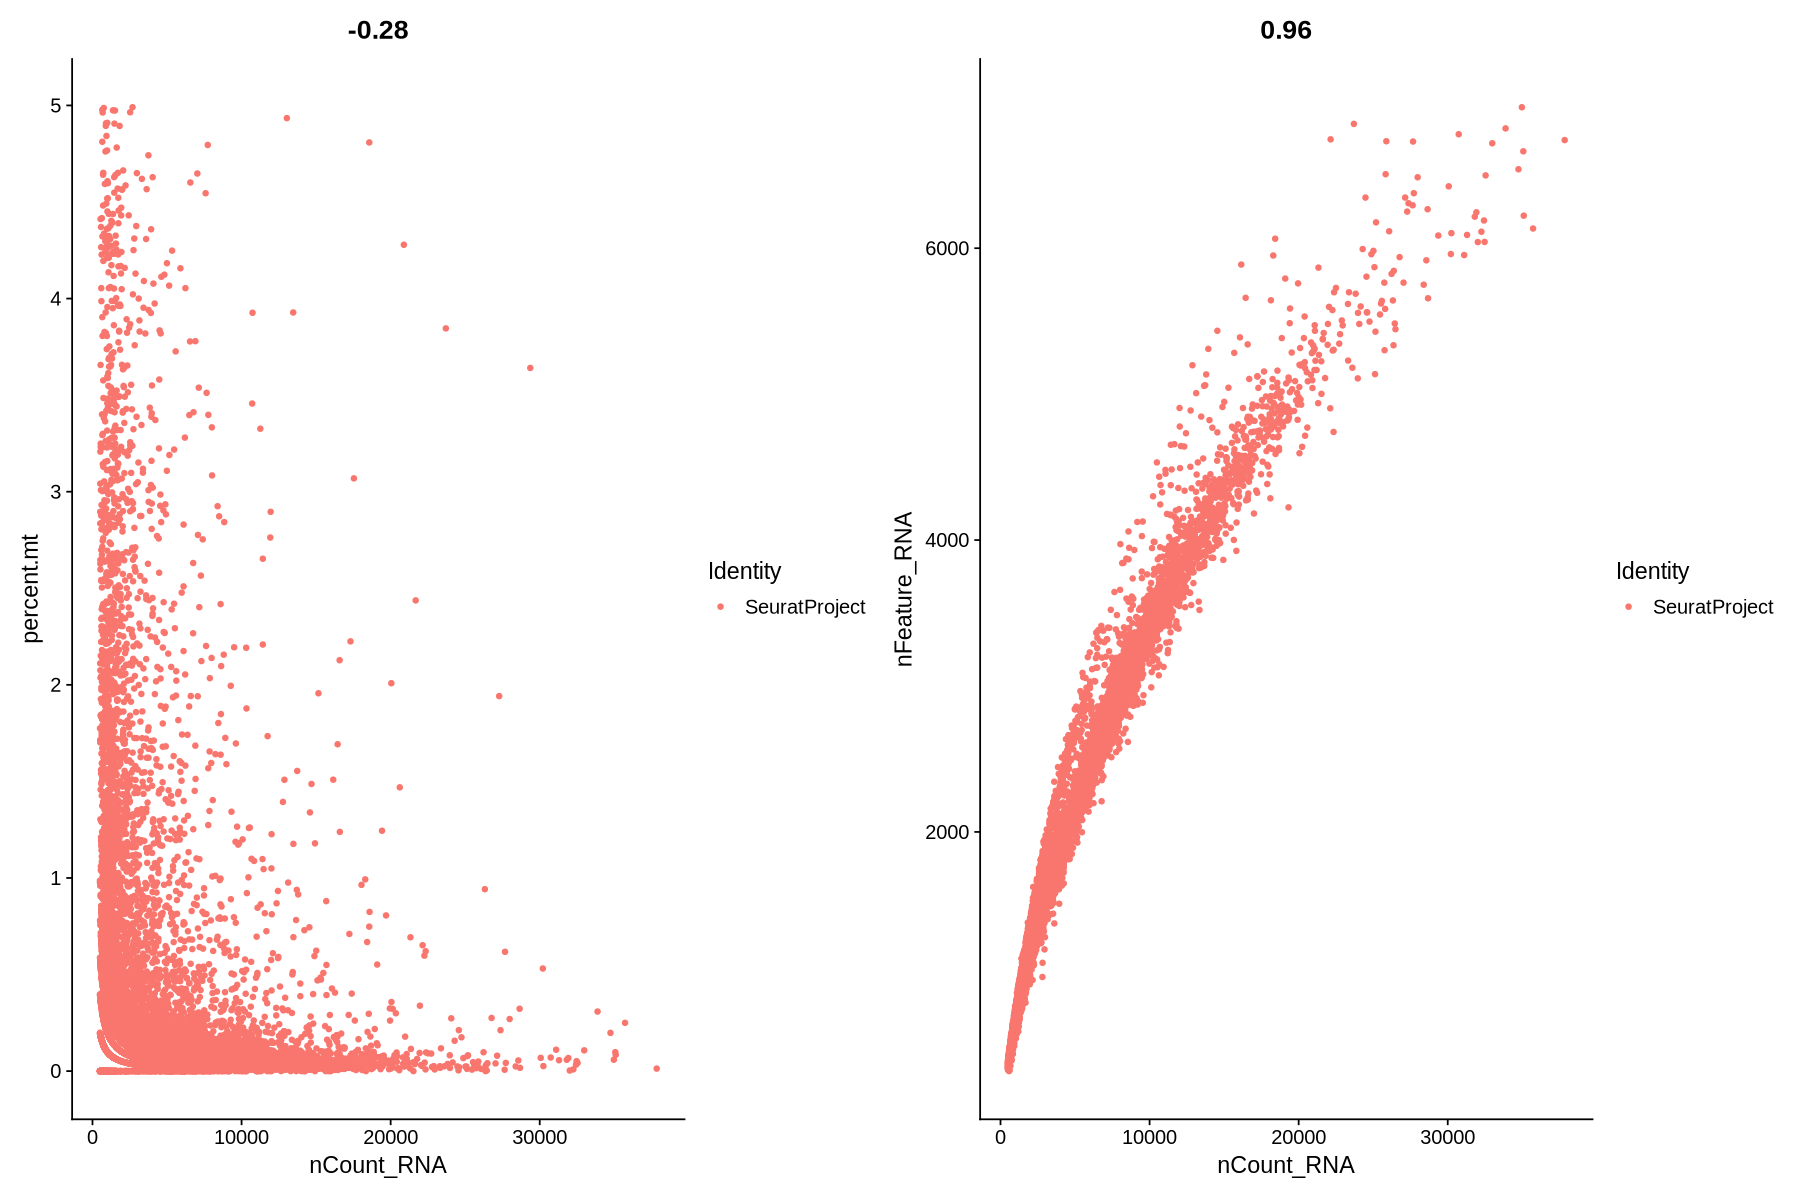

In [11]:
plot1 <- FeatureScatter(heart_cell_atlas, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(heart_cell_atlas, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

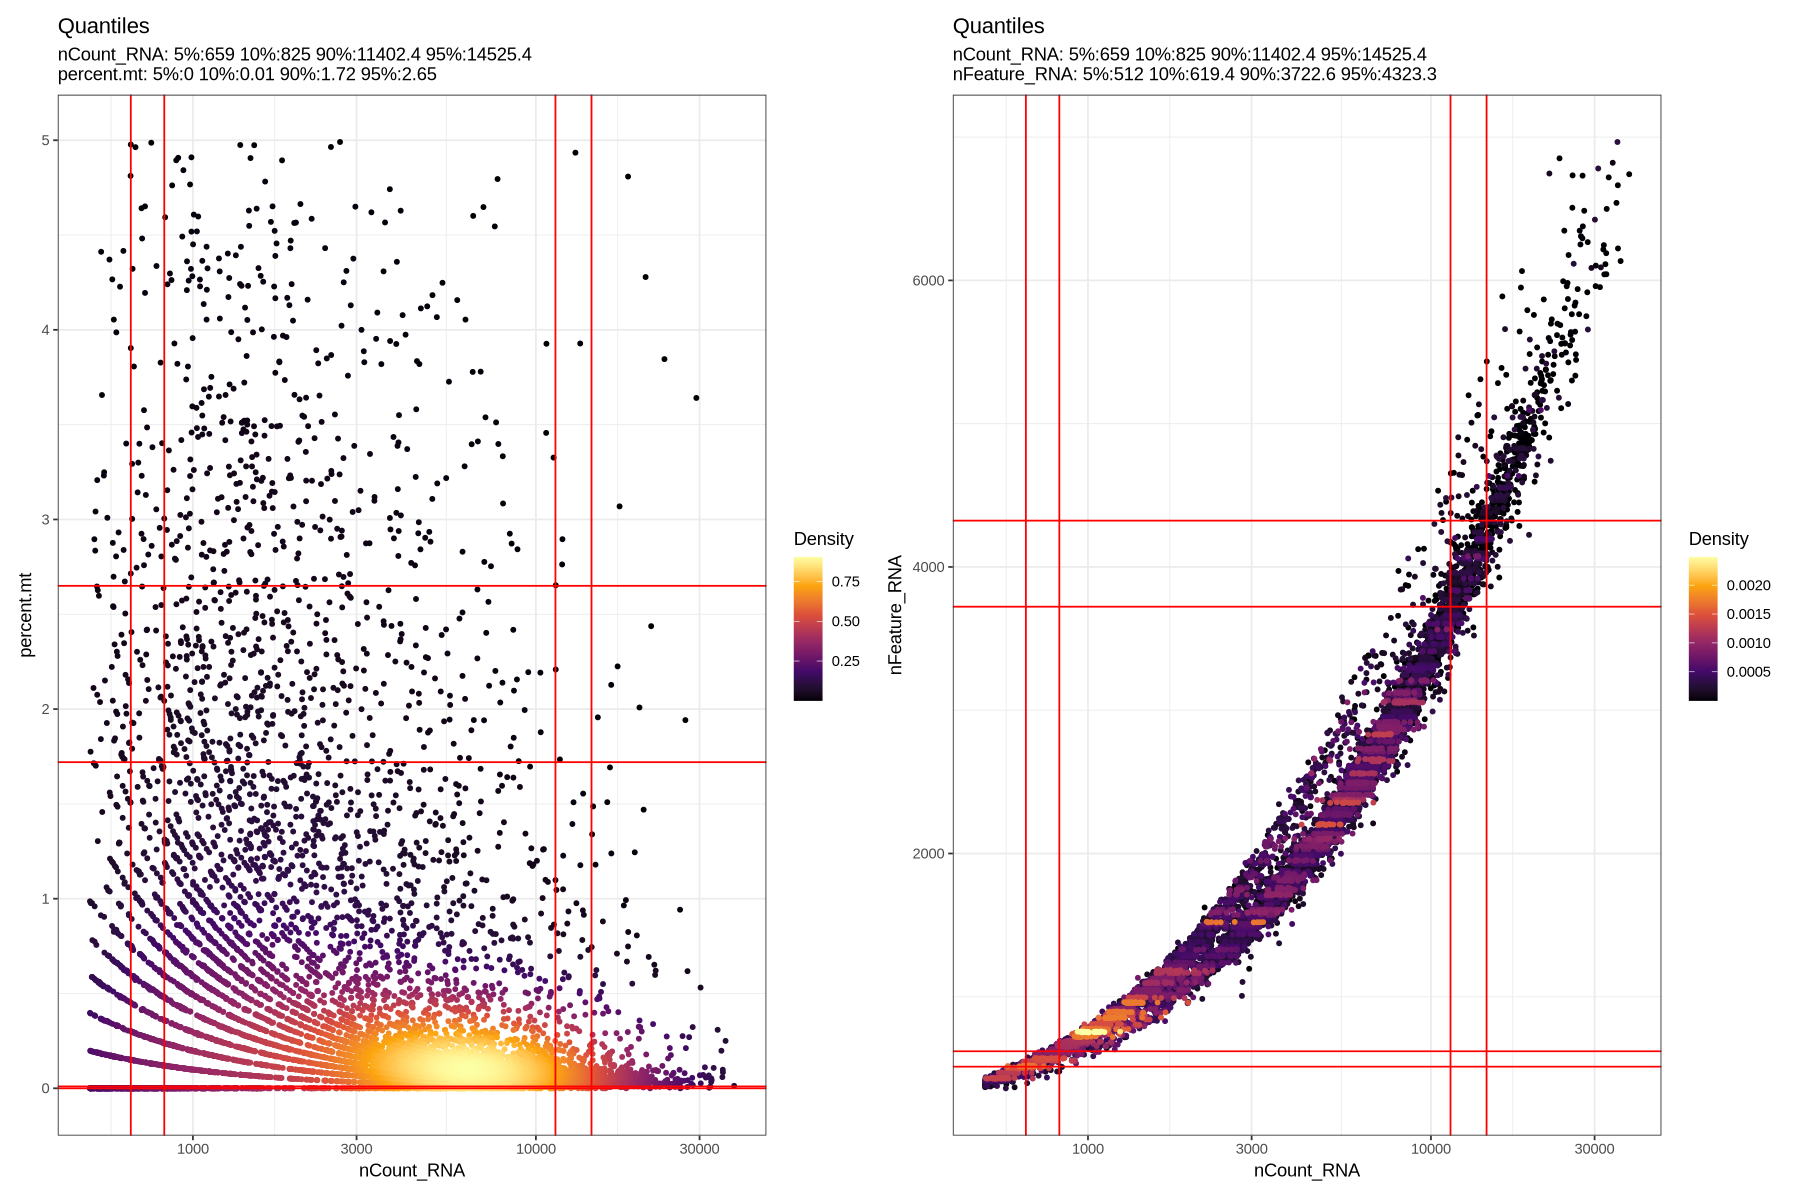

In [12]:
plot1 <-DensityScatter(heart_cell_atlas, x = 'nCount_RNA', y = 'percent.mt', log_x = TRUE, quantiles = TRUE)
plot2 <-DensityScatter(heart_cell_atlas, x = 'nCount_RNA', y = 'nFeature_RNA', log_x = TRUE, quantiles = TRUE)
plot1 + plot2

## ATAC Assay next

In [15]:
DefaultAssay(heart_cell_atlas) <- "Peaks"

heart_cell_atlas <- NucleosomeSignal(heart_cell_atlas)
heart_cell_atlas <- TSSEnrichment(heart_cell_atlas)# Transcription Start Site Enrichment


Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score



In [17]:
colnames(heart_cell_atlas@meta.data)

[1] "orig.ident"                  "nCount_RNA"                 
 [3] "nFeature_RNA"                "sangerID"                   
 [5] "combinedID"                  "donor"                      
 [7] "donor_type"                  "region"                     
 [9] "region_finest"               "age"                        
[11] "gender"                      "facility"                   
[13] "cell_or_nuclei"              "modality"                   
[15] "kit_10x"                     "flushed"                    
[17] "n_genes"                     "n_genes_by_counts"          
[19] "total_counts"                "total_counts_mt"            
[21] "pct_counts_mt"               "total_counts_ribo"          
[23] "pct_counts_ribo"             "scrublet_score"             
[25] "scrublet_leiden"             "cluster_scrublet_score"     
[27] "doublet_pval"                "doublet_bh_pval"            
[29] "batch_key"                   "leiden_scVI"                
[31] "cell_type"                   "cell_state_HCAv1"           
[33] "cell_state_scNym"            "cell_state_scNym_confidence"
[35] "cell_state"                  "latent_RT_efficiency"       
[37] "latent_cell_probability"     "latent_scale"               
[39] "n_counts"                    "_scvi_batch"                
[41] "_scvi_labels"                "clus20"                     
[43] "doublet_cls"                 "original_or_new"            
[45] "batch"                       "scANVI_predictions"         
[47] "leiden_scArches"             "peak_sangerID"              
[49] "peak_combinedID"             "peak_donor"                 
[51] "peak_donor_type"             "peak_region"                
[53] "peak_region_finest"          "peak_age"                   
[55] "peak_gender"                 "peak_facility"              
[57] "peak_cell_or_nuclei"         "peak_modality"              
[59] "peak_kit_10x"                "peak_flushed"               
[61] "peak_batch_key"              "peak_cell_type"             
[63] "peak_cell_state"             "nCount_Peaks"               
[65] "nFeature_Peaks"              "percent.mt"                 
[67] "nucleosome_signal"           "nucleosome_percentile"      
[69] "TSS.enrichment"              "TSS.percentile"

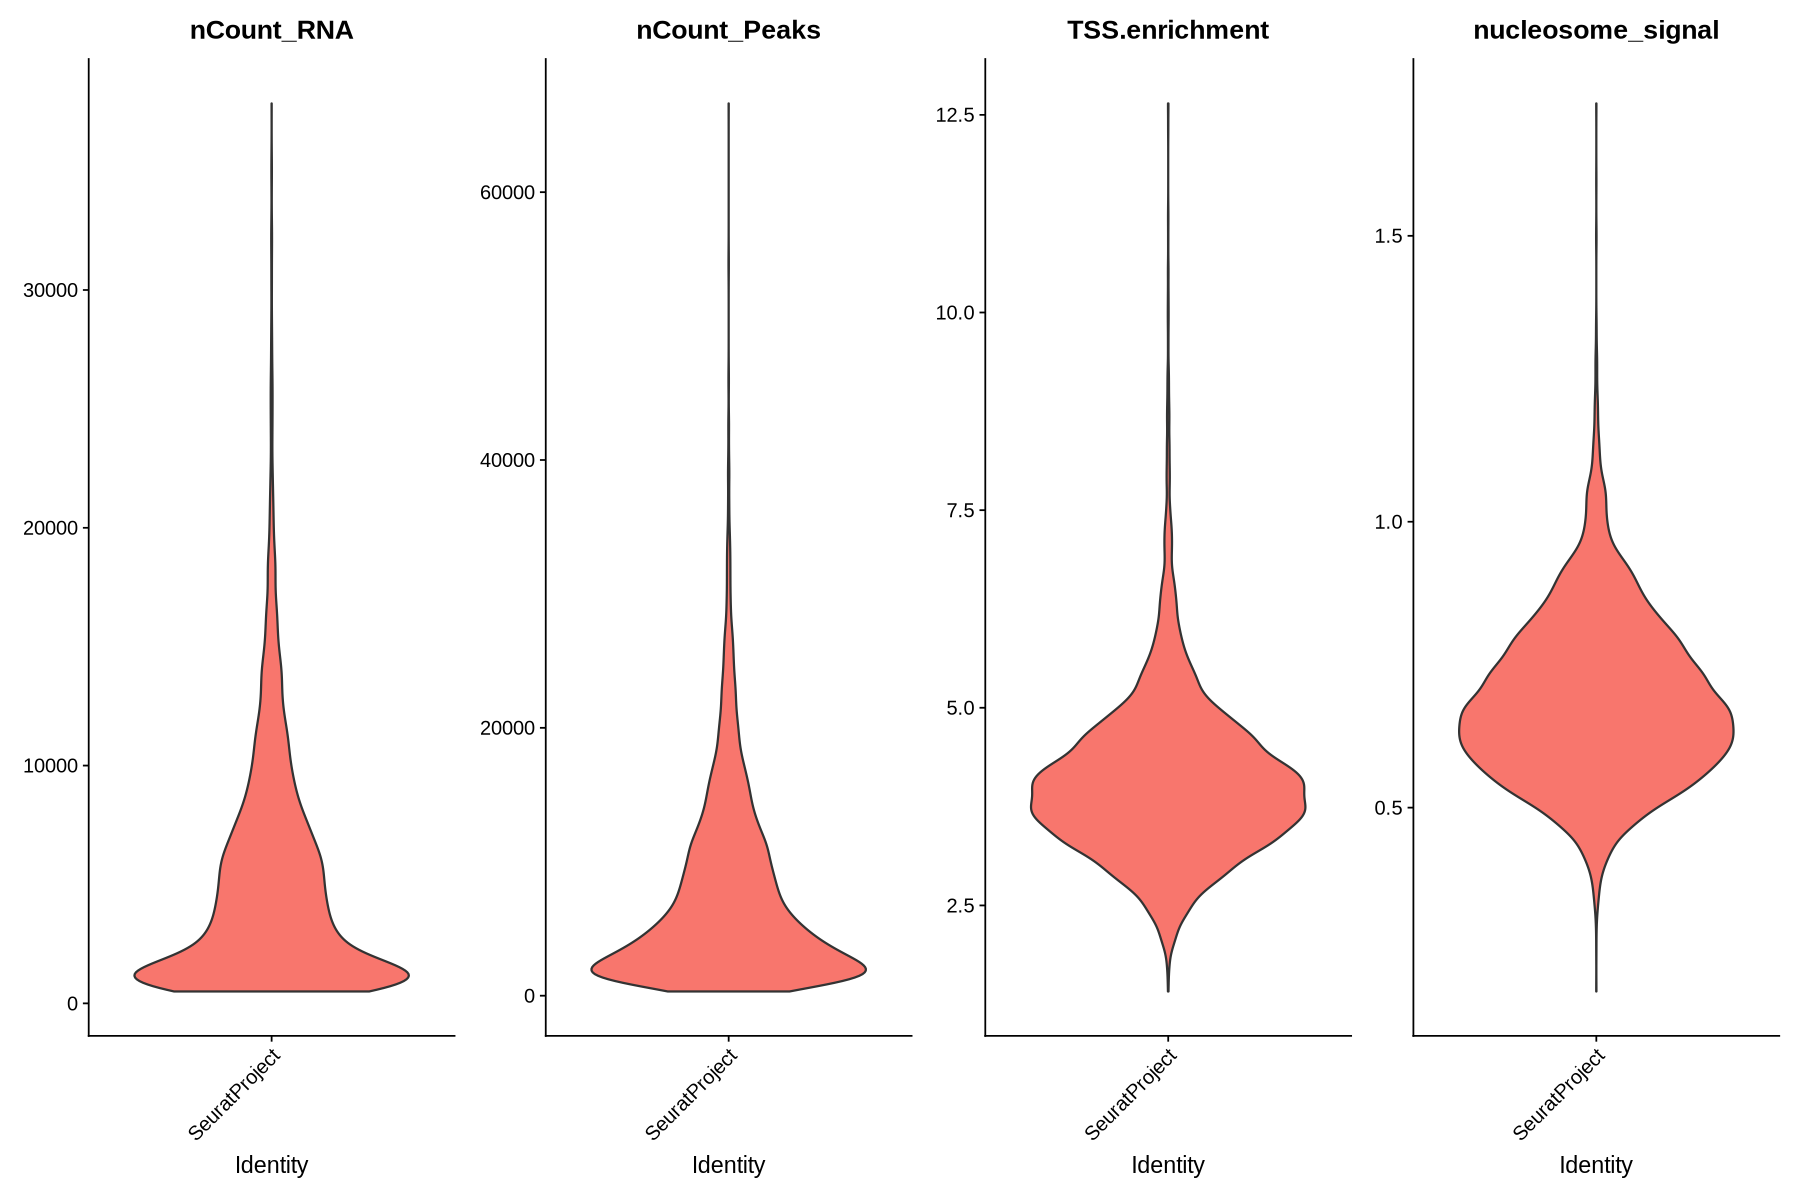

In [18]:

VlnPlot(
  object = heart_cell_atlas,
  features = c("nCount_RNA", "nCount_Peaks", "TSS.enrichment", "nucleosome_signal"),
  ncol = 4,
  pt.size = 0
)

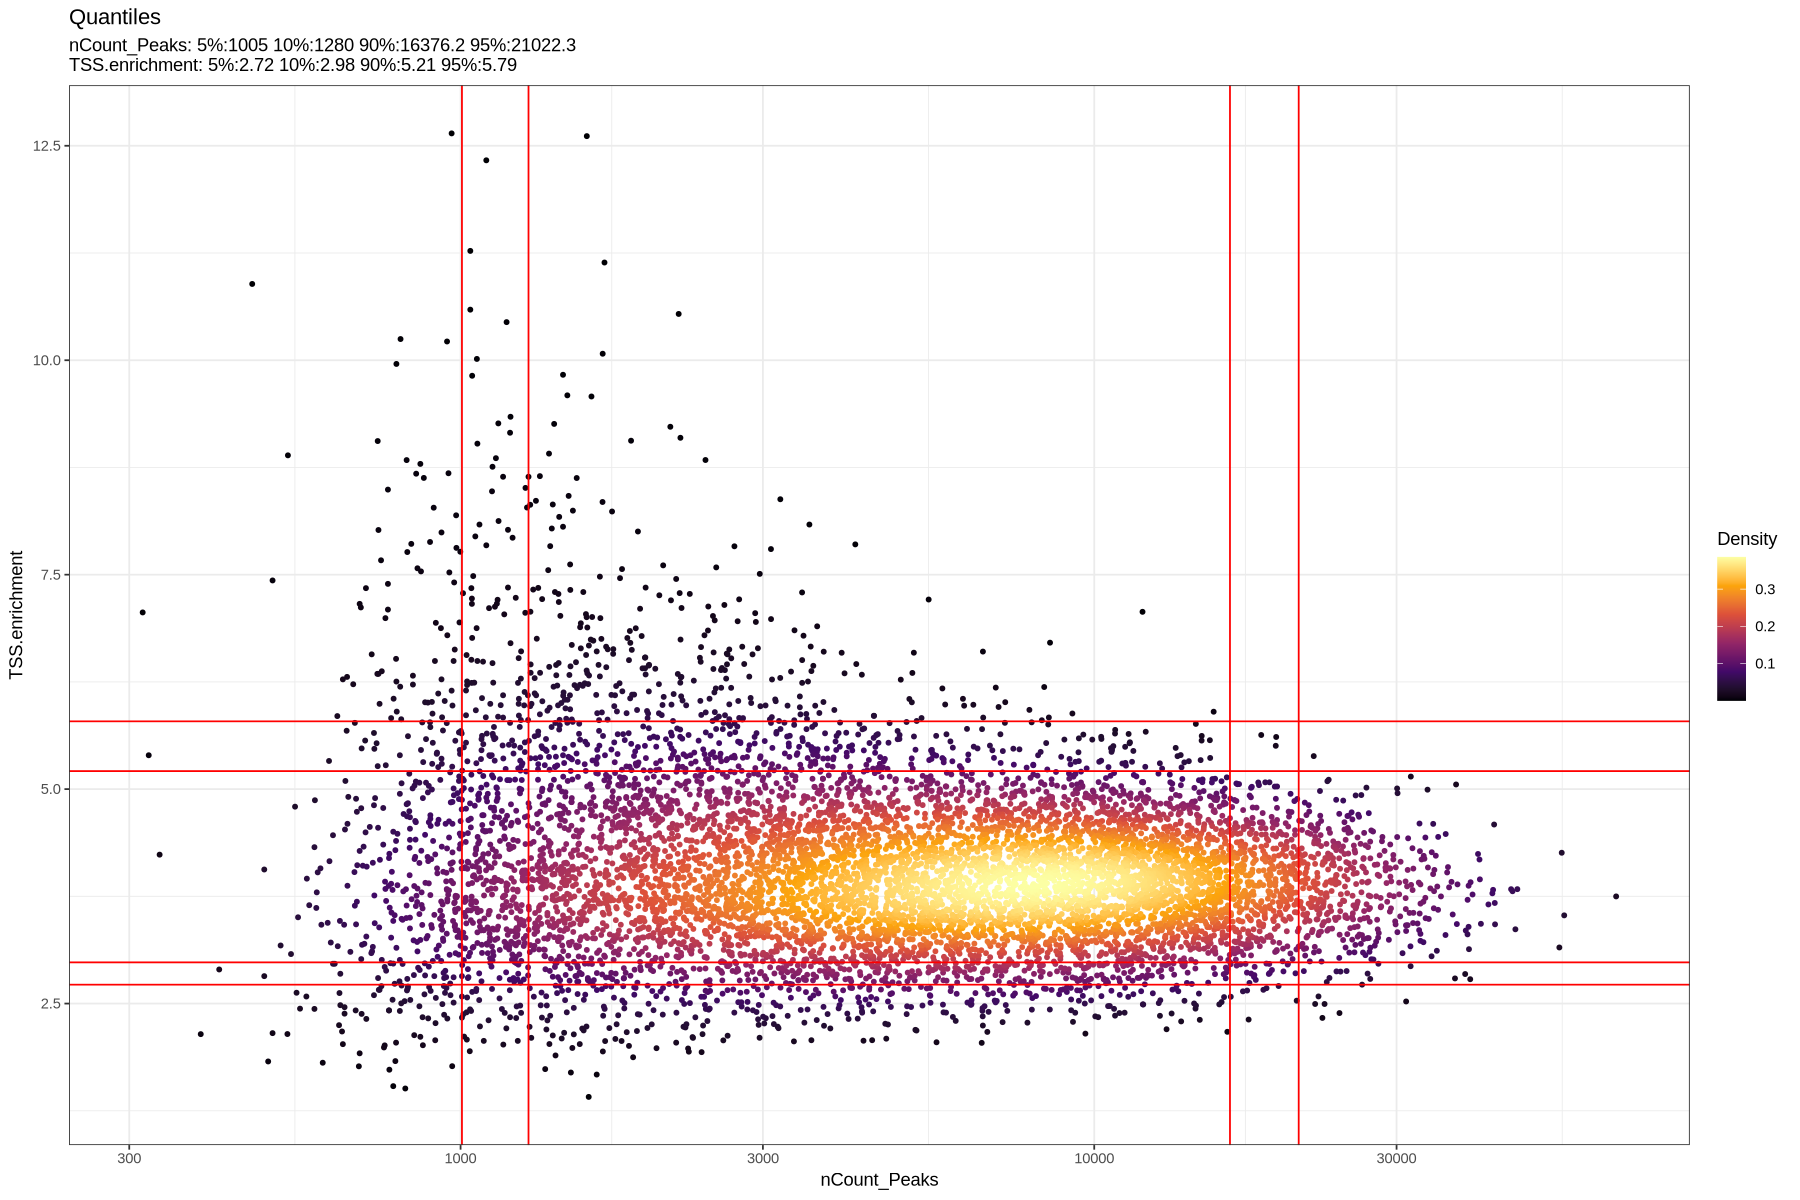

In [20]:
DensityScatter(heart_cell_atlas, x = 'nCount_Peaks', y = 'TSS.enrichment', log_x = TRUE, quantiles = TRUE)

In [23]:
# Because very low nCount_RNA usually means the barcode captured too little RNA to represent a real, informative cell.
# nCount_RNA is the total UMI count per cell. When it is very low, several problems become more likely:
# the droplet may be empty or nearly empty
# it may contain ambient RNA rather than a true cell
# the cell may be damaged or partially lysed
# gene expression becomes very sparse and noisy, so clustering and marker detection get worse
# So a cutoff like nCount_RNA > 500 is just a practical way to remove the weakest barcodes.


In [21]:
nCount_RNALOW=quantile(heart_cell_atlas$nCount_RNA, prob=c(0.01))  
nCount_RNAHIGH=quantile(heart_cell_atlas$nCount_RNA, prob=0.99) 
nCount_ATACLOW=quantile(heart_cell_atlas$nCount_Peaks, prob=c(0.01))  
nCount_ATACHIGH=quantile(heart_cell_atlas$nCount_Peaks, prob=0.99)

In [22]:
nCount_RNALOW
nCount_RNAHIGH
nCount_ATACLOW
nCount_ATACHIGH

1% 
536

99% 
21885.54

1% 
710.34

99% 
31209.24

In [26]:
heart_cell_atlas <- subset(
  x = heart_cell_atlas,
  subset = nCount_Peaks < 30000 &
    nCount_RNA < 20000 &
    nCount_Peaks > 700 &
    nCount_RNA > 500 &
    nucleosome_signal < 2 &
    TSS.enrichment > 1
)
heart_cell_atlas

An object of class Seurat 
462560 features across 8358 samples within 2 assays 
Active assay: Peaks (429828 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: RNA

## CALL PEAKS using CallPeaks() with MACS2

- call peaks on all cells together
- opt: identify peaks for each group of cells separately: group.by parameter -> identify peaks specific to rare cell populations

In [28]:
path_to_macs2 = '/nfs/home/students/m.back/.conda/envs/mzb_macs2/bin/macs2'

In [29]:
path_to_macs2

[1] "/nfs/home/students/m.back/.conda/envs/mzb_macs2/bin/macs2"

In [31]:

path_to_macs2 = '/nfs/home/students/m.back/.conda/envs/mzb_macs2_py310/bin/macs2'

DefaultAssay(heart_cell_atlas) <- "Peaks"
peaks_macs2 <- CallPeaks(heart_cell_atlas, 
                    macs2.path=path_to_macs2, 
                    outdir = out_dir,
                    # effective.genome.size = 2.7e9, 
                    cleanup = FALSE
                    )
peaks_macs2

GRanges object with 126975 ranges and 6 metadata columns:
             seqnames            ranges strand |                   name
                <Rle>         <IRanges>  <Rle> |            <character>
       [1] GL000194.1       21353-21611      * |   SeuratProject_peak_1
       [2] GL000194.1       24168-25355      * |   SeuratProject_peak_2
       [3] GL000194.1       55936-56674      * |   SeuratProject_peak_3
       [4] GL000194.1       58297-58724      * |   SeuratProject_peak_4
       [5] GL000194.1       59794-60263      * |   SeuratProject_peak_5
       ...        ...               ...    ... .                    ...
  [126971]       chrY 56857848-56858244      * | SeuratProject_peak_1..
  [126972]       chrY 56858619-56859060      * | SeuratProject_peak_1..
  [126973]       chrY 56861338-56861684      * | SeuratProject_peak_1..
  [126974]       chrY 56869767-56870173      * | SeuratProject_peak_1..
  [126975]       chrY 56870799-56871078      * | SeuratProject_peak_1..
      

## remove peaks on nonstandard chromosomes and in genomic blacklist regions

genomic blacklist regions:
- these regions are prone to produce misleading or false-positive signals
- due to factors like repetitive sequences, mapping errors, or experimental artifacts.

In [32]:
peaks_macs2 <- keepStandardChromosomes(peaks_macs2, pruning.mode = "coarse")
peaks_macs2 <- subsetByOverlaps(x = peaks_macs2, ranges = blacklist_hg38_unified, invert = TRUE) # exclude gbrs (as invert is set to true)  

In [33]:
# quantify counts in each peak
macs2_counts <- FeatureMatrix(
  fragments = Fragments(heart_cell_atlas),
  features = peaks_macs2,
  cells = colnames(heart_cell_atlas)
)

Extracting reads overlapping genomic regions



In [35]:
annotation <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [37]:
seqlevels(annotation) <- paste0("chr", seqlevels(annotation))
annotation

GRanges object with 3021151 ranges and 5 metadata columns:
                  seqnames        ranges strand |           tx_id   gene_name
                     <Rle>     <IRanges>  <Rle> |     <character> <character>
  ENSE00001489430     chrX 276322-276394      + | ENST00000399012      PLCXD1
  ENSE00001536003     chrX 276324-276394      + | ENST00000484611      PLCXD1
  ENSE00002160563     chrX 276353-276394      + | ENST00000430923      PLCXD1
  ENSE00001750899     chrX 281055-281121      + | ENST00000445062      PLCXD1
  ENSE00001489388     chrX 281192-281684      + | ENST00000381657      PLCXD1
              ...      ...           ...    ... .             ...         ...
  ENST00000361739    chrMT     7586-8269      + | ENST00000361739      MT-CO2
  ENST00000361789    chrMT   14747-15887      + | ENST00000361789      MT-CYB
  ENST00000361851    chrMT     8366-8572      + | ENST00000361851     MT-ATP8
  ENST00000361899    chrMT     8527-9207      + | ENST00000361899     MT-ATP6
  ENS

In [39]:
sample_to_use <- "HCAHeartST11350194_HCAHeartST11445771"
fragpath <- paste0("/nfs/data3/mopitas/mapra/cell_atlas_data/", sample_to_use, "_atac_fragments.tsv.gz")

stopifnot(file.exists(fragpath))

In [40]:
# create a new assay using the MACS2 peak set and add it to the Seurat object
heart_cell_atlas[["peaks_macs2"]] <- CreateChromatinAssay(
  counts = macs2_counts,
  fragments = fragpath,
  annotation = annotation
)
heart_cell_atlas

Computing hash



An object of class Seurat 
589306 features across 8358 samples within 3 assays 
Active assay: Peaks (429828 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: RNA, peaks_macs2

In [42]:
heart_cell_atlas[["peaks_macs2"]]@data[1:20,1:10]

  [[ suppressing 10 column names 'AGGTATTGTCTTTGAC-1', 'ACTTACTTCATTAGTG-1', 'CCTTCAATCAGCATTA-1' ... ]]



20 x 10 sparse Matrix of class "dgCMatrix"
                                      
chr1-180726-181592 . . . . . . . . . .
chr1-191296-191598 . 1 . . . . . . . .
chr1-777673-779298 . . . . . . . . . .
chr1-816970-817414 . . . . . . . . . .
chr1-826849-827669 . . . . . . . . . .
chr1-831309-831553 . . . . . . . . . .
chr1-832099-832600 . . . . . . . . . .
chr1-837599-837798 . . . . . . . . . .
chr1-843950-844232 . . . . . . . . . .
chr1-844553-844950 . . . . . . . . . .
chr1-849979-850595 . . . . . . . . . .
chr1-856155-856369 . . . . . . . . . .
chr1-858626-859058 . . . 1 1 . . . . .
chr1-865187-866425 . . . . . . . . 1 .
chr1-869542-870192 . . . . . . . . . .
chr1-875330-875555 . . . . . . . . . .
chr1-876313-876970 . . . . . . . . . .
chr1-903855-905483 . . . . . . . . . .
chr1-906729-907018 . . . . . . . . . .
chr1-909973-910699 . . . . . . . . . .

In [44]:
saveRDS(heart_cell_atlas, file = paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called.rds"), compress = "xz") 

## Normalization and PCA
### Gene expression (RNA) data processing

- normalize gene expression data: SCTransform

It uses a regularized negative binomial regression model to estimate the mean-variance relationship of each gene, allowing for the transformation of the data to a more approximately normal distribution. This transformation helps to reduce the dependence of variance on the mean, which is often observed in scRNA-seq data

- reduce the dimensionality: PCA

In [45]:
library(glmGamPoi)


Attaching package: 'glmGamPoi'


The following object is masked from 'package:dplyr':

    vars


The following object is masked from 'package:ggplot2':

    vars




In [46]:
DefaultAssay(heart_cell_atlas) <- "RNA"

heart_cell_atlas <- SCTransform(  # this is an alternative to NormalizeData + FindVariableFeatures + ScaleData
  heart_cell_atlas,
  vst.flavor = "v2",
  method = "glmGamPoi", # fast Poisson-Gamma model
  variable.features.n = 3000,
  conserve.memory = TRUE, # useful for large data
  verbose = TRUE)
  
heart_cell_atlas <- RunPCA(heart_cell_atlas, reduction.name = "pca_sct")

Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi



Variance stabilizing transformation of count matrix of size 22272 by 8358

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells

Found 186 outliers - those will be ignored in fitting/regularization step


Skip calculation of full residual matrix

Will not return corrected UMI because residual type is not set to 'pearson'

Calculating gene attributes

Wall clock passed: Time difference of 16.8824 secs

Setting min_variance based on median UMI:  0.04

Calculating variance for residuals of type pearson for 22272 genes

Determine variable features

Setting min_variance based on median UMI:  0.04

Calculating residuals of type pearson for 3000 genes



  |======================================================================| 100%


Computing corrected UMI count matrix

Centering data matrix

Place corrected count matrix in counts slot

Set default assay to SCT

PC_ 1 
Positive:  ENSG00000114279, ENSG00000115641, ENSG00000198626, ENSG00000154556, ENSG00000183230, ENSG00000198947, ENSG00000004799, ENSG00000172572, ENSG00000183023, ENSG00000165995 
	   ENSG00000078114, ENSG00000146147, ENSG00000205678, ENSG00000148677, ENSG00000155657, ENSG00000151067, ENSG00000237298, ENSG00000151320, ENSG00000170624, ENSG00000163110 
	   ENSG00000116783, ENSG00000134775, ENSG00000186073, ENSG00000164309, ENSG00000203867, ENSG00000099204, ENSG00000134571, ENSG00000101605, ENSG00000187720, ENSG00000169306 
Negative:  ENSG00000011465, ENSG00000172260, ENSG00000166147, ENSG00000122870, ENSG00000120594, ENSG00000154262, ENSG00000085276, ENSG00000164330, ENSG00000111341, ENSG00000148180 
	   ENSG00000163359, ENSG00000154258, ENSG00000086991, ENSG00000071991, ENSG00000091986, ENSG00000124212, ENSG00000038427, ENSG00000111799, ENSG0000016

In [47]:

DefaultAssay(heart_cell_atlas) <- "RNA"

heart_cell_atlas <- NormalizeData(heart_cell_atlas)
heart_cell_atlas <- FindVariableFeatures(heart_cell_atlas)
heart_cell_atlas <- ScaleData(heart_cell_atlas)
heart_cell_atlas <- RunPCA(heart_cell_atlas, reduction.name = "pca_rna")

Normalizing layer: counts



Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  ENSG00000115641, ENSG00000205678, ENSG00000237298, ENSG00000198947, ENSG00000114279, ENSG00000186073, ENSG00000184305, ENSG00000184349, ENSG00000261115, ENSG00000170624 
	   ENSG00000229618, ENSG00000145934, ENSG00000170153, ENSG00000153820, ENSG00000178568, ENSG00000004799, ENSG00000181072, ENSG00000197893, ENSG00000182732, ENSG00000112137 
	   ENSG00000115896, ENSG00000109819, ENSG00000112530, ENSG00000148677, ENSG00000109452, ENSG00000132938, ENSG00000182836, ENSG00000169851, ENSG00000112319, ENSG00000169306 
Negative:  ENSG00000011465, ENSG00000120594, ENSG00000166147, ENSG00000164330, ENSG00000122870, ENSG00000154262, ENSG00000085276, ENSG00000196628, ENSG00000172260, ENSG00000168477 
	   ENSG00000164692, ENSG00000163359, ENSG00000148180, ENSG00000111341, ENSG00000154258, ENSG00000124212, ENSG00000117020, ENSG00000221818, ENSG00000152583, ENSG00000091986 
	   ENSG00000144810, ENSG00000

## DNA accessibility (peaks) data processing

latent semantic indexing (LSI)-> latent space using SVD and dimensionality reduction

In [48]:
DefaultAssay(heart_cell_atlas) <- "peaks_macs2"
heart_cell_atlas <- FindTopFeatures(heart_cell_atlas, min.cutoff = 5)
heart_cell_atlas <- RunTFIDF(heart_cell_atlas)
heart_cell_atlas <- RunSVD(heart_cell_atlas)

Performing TF-IDF normalization



Running SVD

Scaling cell embeddings



## joined CLUSTERING and UMAP
Questions:

which assay? SCT or RNA? or does it not matter? should use rna and peaks -> in the object it says: assay.used = SCT

In [49]:
options(repr.plot.width=16, repr.plot.height=5)

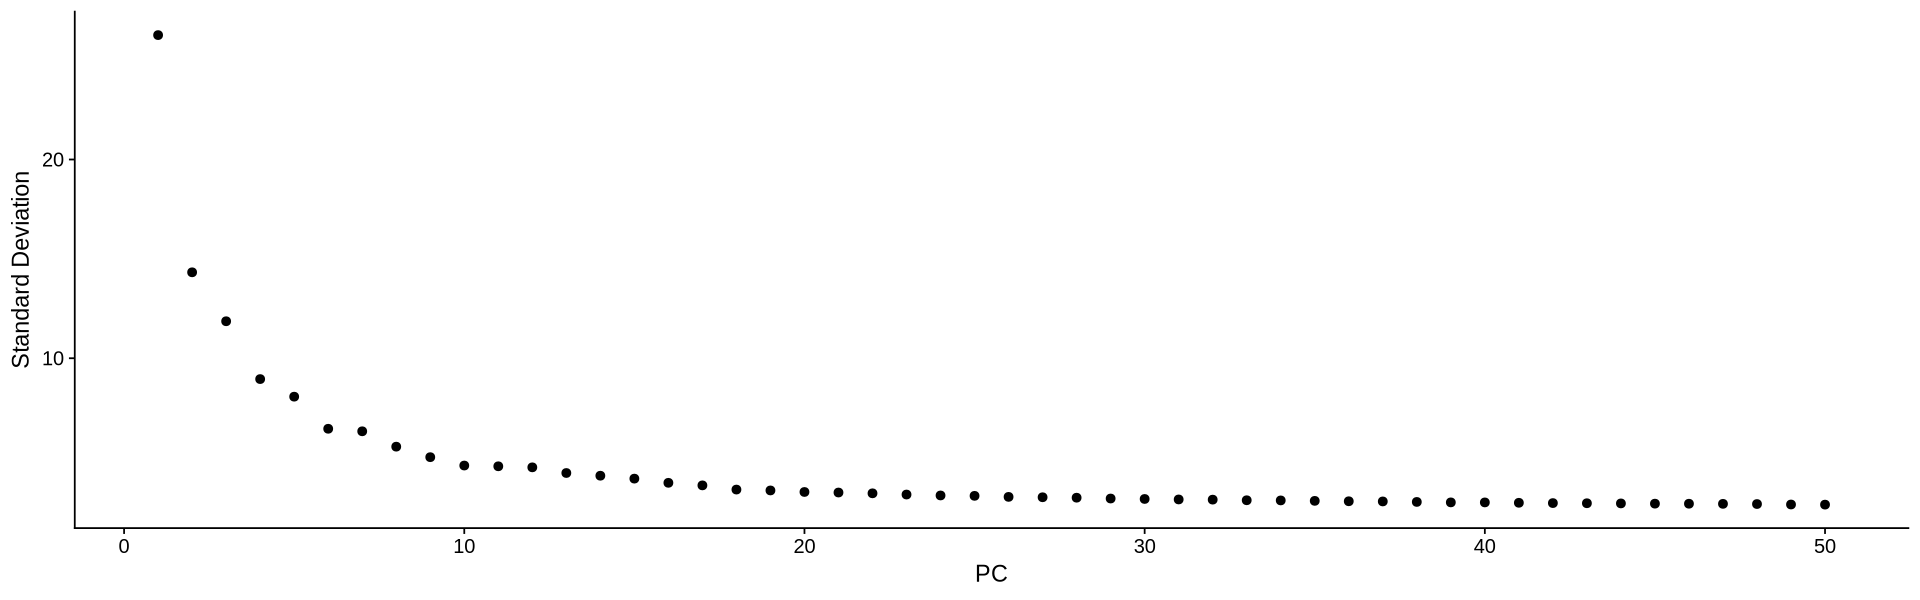

In [50]:
DefaultAssay(heart_cell_atlas) <- "SCT"
ElbowPlot(heart_cell_atlas, ndims = 50, reduction = "pca_sct")

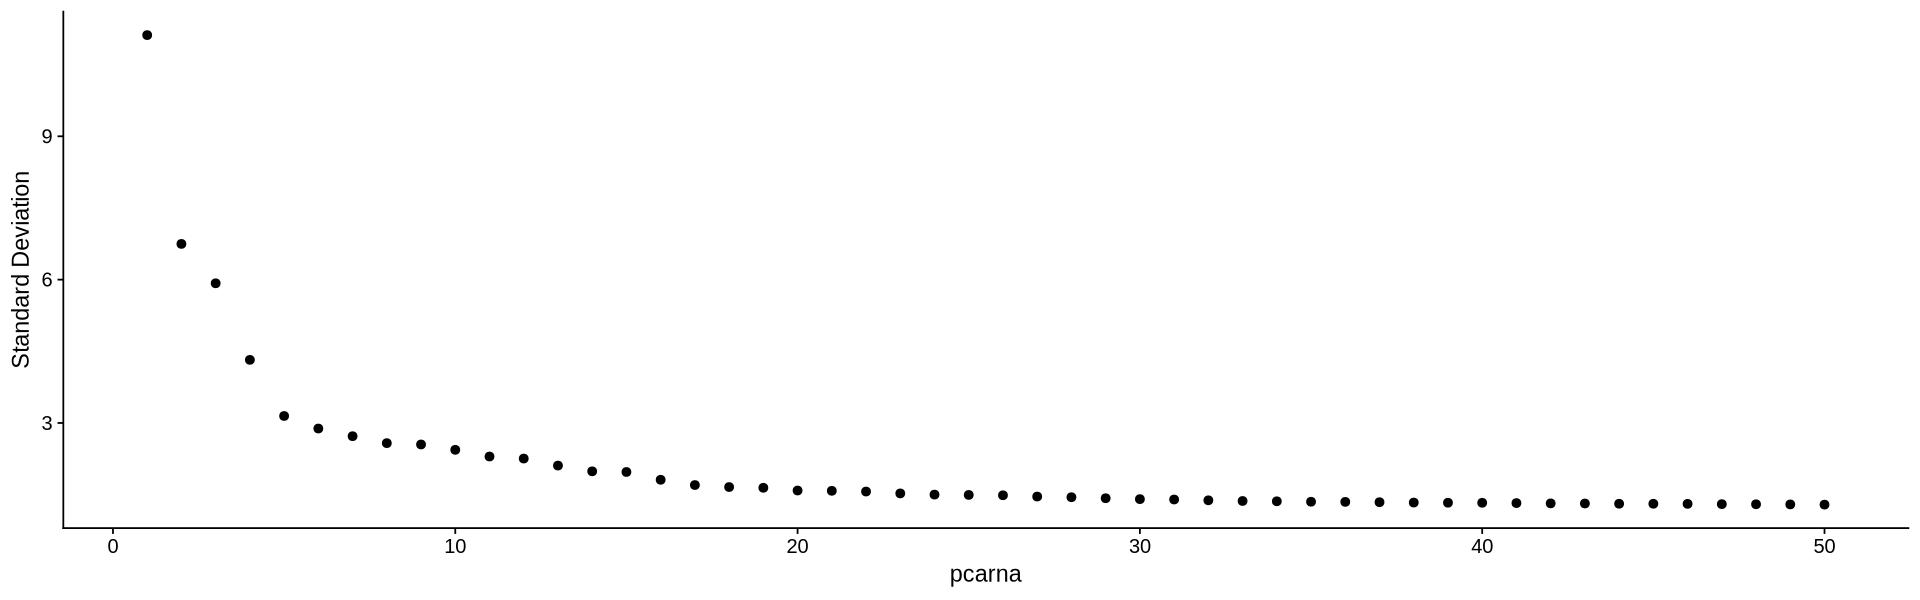

In [52]:
DefaultAssay(heart_cell_atlas) <- "RNA"
ElbowPlot(heart_cell_atlas, ndims = 50, reduction = "pca_rna")

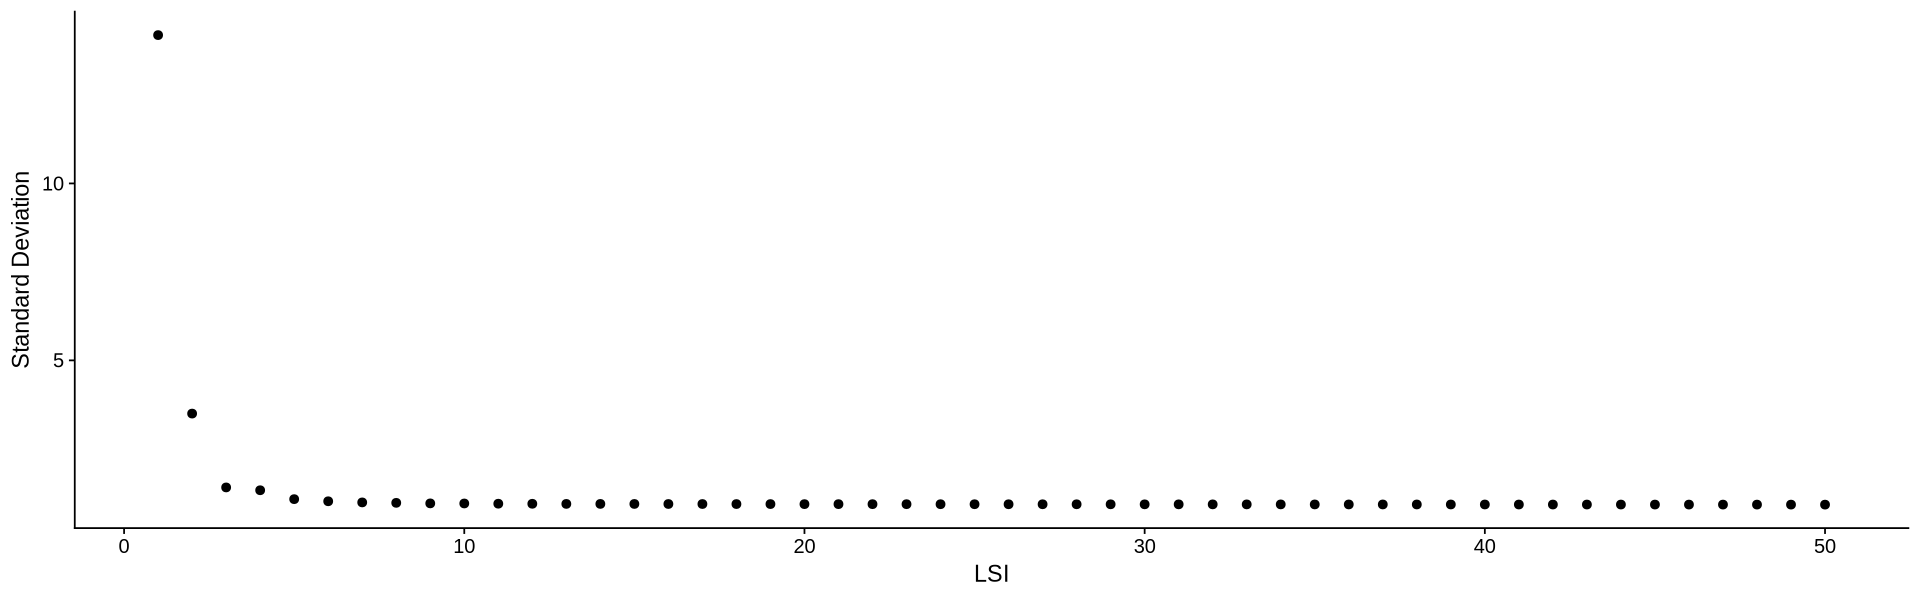

In [ ]:
DefaultAssay(heart_cell_atlas) <- "peaks_macs2"
ElbowPlot(heart_cell_atlas, ndims = 50, reduction = "lsi")

In [54]:
heart_cell_atlas

An object of class Seurat 
611578 features across 8358 samples within 4 assays 
Active assay: peaks_macs2 (126746 features, 126741 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, Peaks, SCT
 3 dimensional reductions calculated: pca_sct, pca_rna, lsi

## Reduction on RNA and peaks assay

In [55]:
DefaultAssay(heart_cell_atlas) <- "RNA" 
# build a joint neighbor graph using both assays
heart_cell_atlas <- FindMultiModalNeighbors(
  object = heart_cell_atlas,
  reduction.list = list("pca_rna", "lsi"), # on RNA and on peaks
  dims.list = list(1:30, 2:15),
  k.nn = 10,
  knn.graph.name = "wknn_RNA_peaks",
  snn.graph.name = "wsnn_RNA_peaks",
  weighted.nn.name = "weighted.nn.RNA_peaks",
  modality.weight.name = c("RNA.weight","peaks.weight"),
  verbose = TRUE
)

Calculating cell-specific modality weights

Finding 10 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph



In [56]:
# build a joint UMAP visualization
heart_cell_atlas <- RunUMAP(
  object = heart_cell_atlas,
  nn.name = "weighted.nn.RNA_peaks",
  reduction.name = "umap_RNA_peaks",
  verbose = TRUE
)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
20:28:19 UMAP embedding parameters a = 0.9922 b = 1.112

20:28:21 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 10

20:28:24 Initializing from normalized Laplacian + noise (using RSpectra)

20:28:24 Commencing optimization for 500 epochs, with 134444 positive edges

20:28:24 Using rng type: pcg

20:28:35 Optimization finished



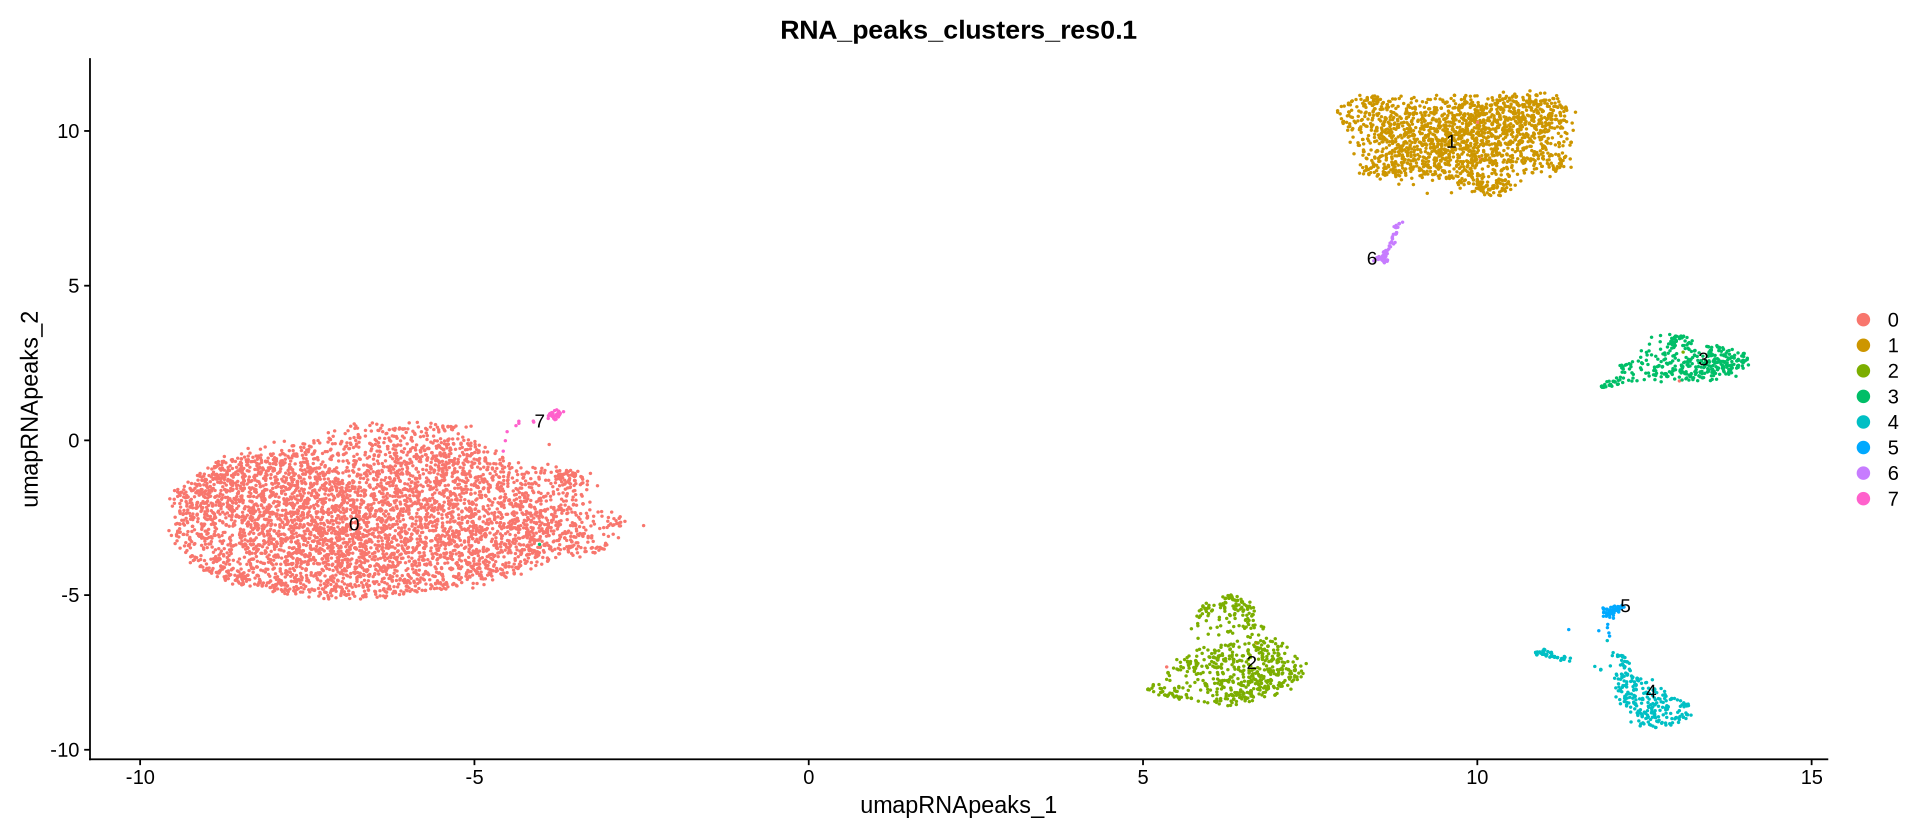

In [59]:
options(repr.plot.width=16, repr.plot.height=7)
heart_cell_atlas <- FindClusters(heart_cell_atlas, resolution = 0.1,verbose=FALSE, graph.name="wsnn_RNA_peaks", cluster.name = "RNA_peaks_clusters_res0.1")
DimPlot(heart_cell_atlas, reduction = "umap_RNA_peaks", group.by = "RNA_peaks_clusters_res0.1", label = TRUE, repel = TRUE)

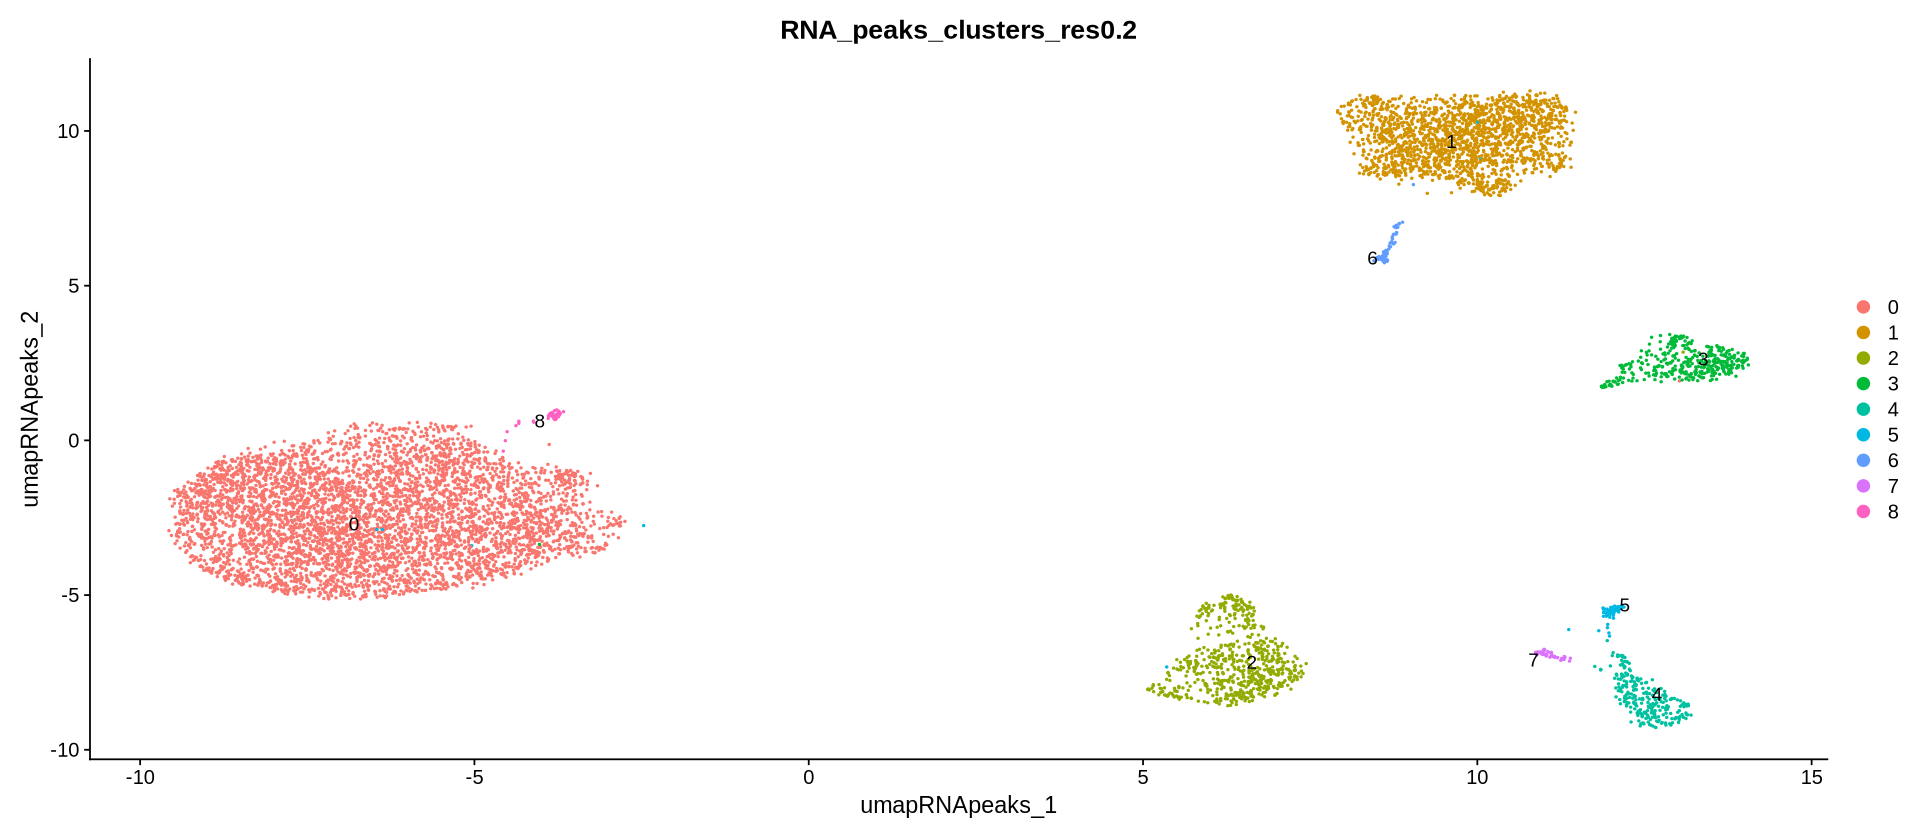

In [57]:
options(repr.plot.width=16, repr.plot.height=7)
heart_cell_atlas <- FindClusters(heart_cell_atlas, resolution = 0.2,verbose=FALSE, graph.name="wsnn_RNA_peaks", cluster.name = "RNA_peaks_clusters_res0.2")
DimPlot(heart_cell_atlas, reduction = "umap_RNA_peaks", group.by = "RNA_peaks_clusters_res0.2", label = TRUE, repel = TRUE)

## Reduction on SCT and peaks assay

Calculating cell-specific modality weights



Finding 10 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

20:31:11 UMAP embedding parameters a = 0.9922 b = 1.112

20:31:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 10

20:31:15 Initializing from normalized Laplacian + noise (using RSpectra)

20:31:15 Commencing optimization for 500 epochs, with 136040 positive edges

20:31:15 Using rng type: pcg

20:31:26 Optimization finished



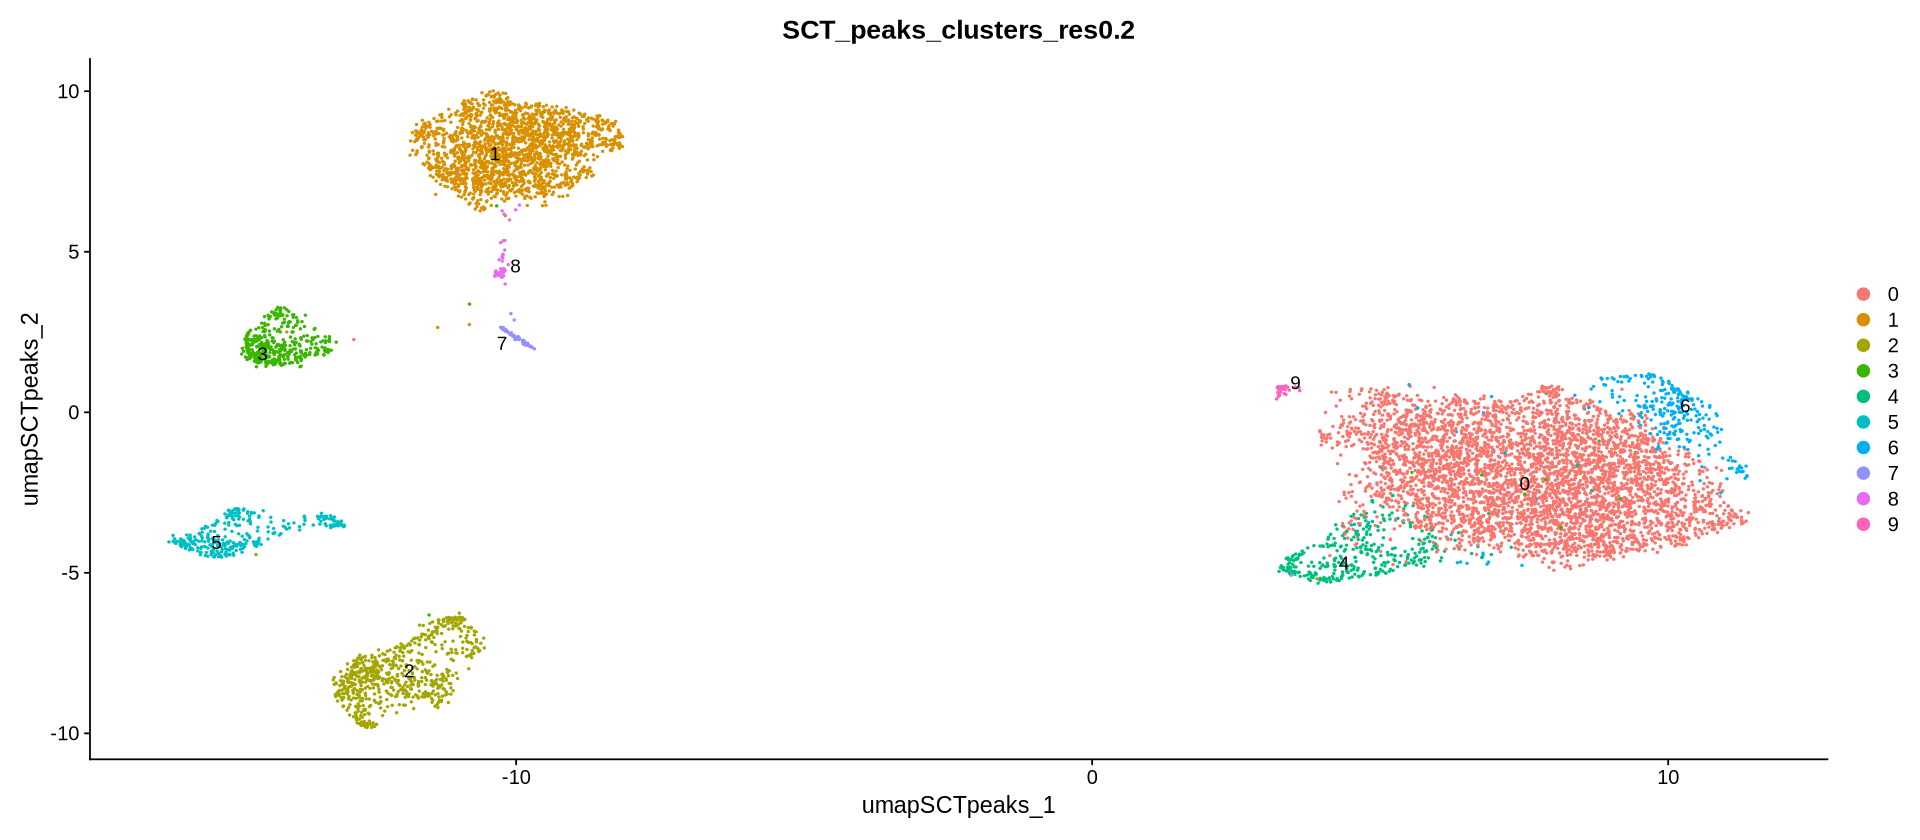

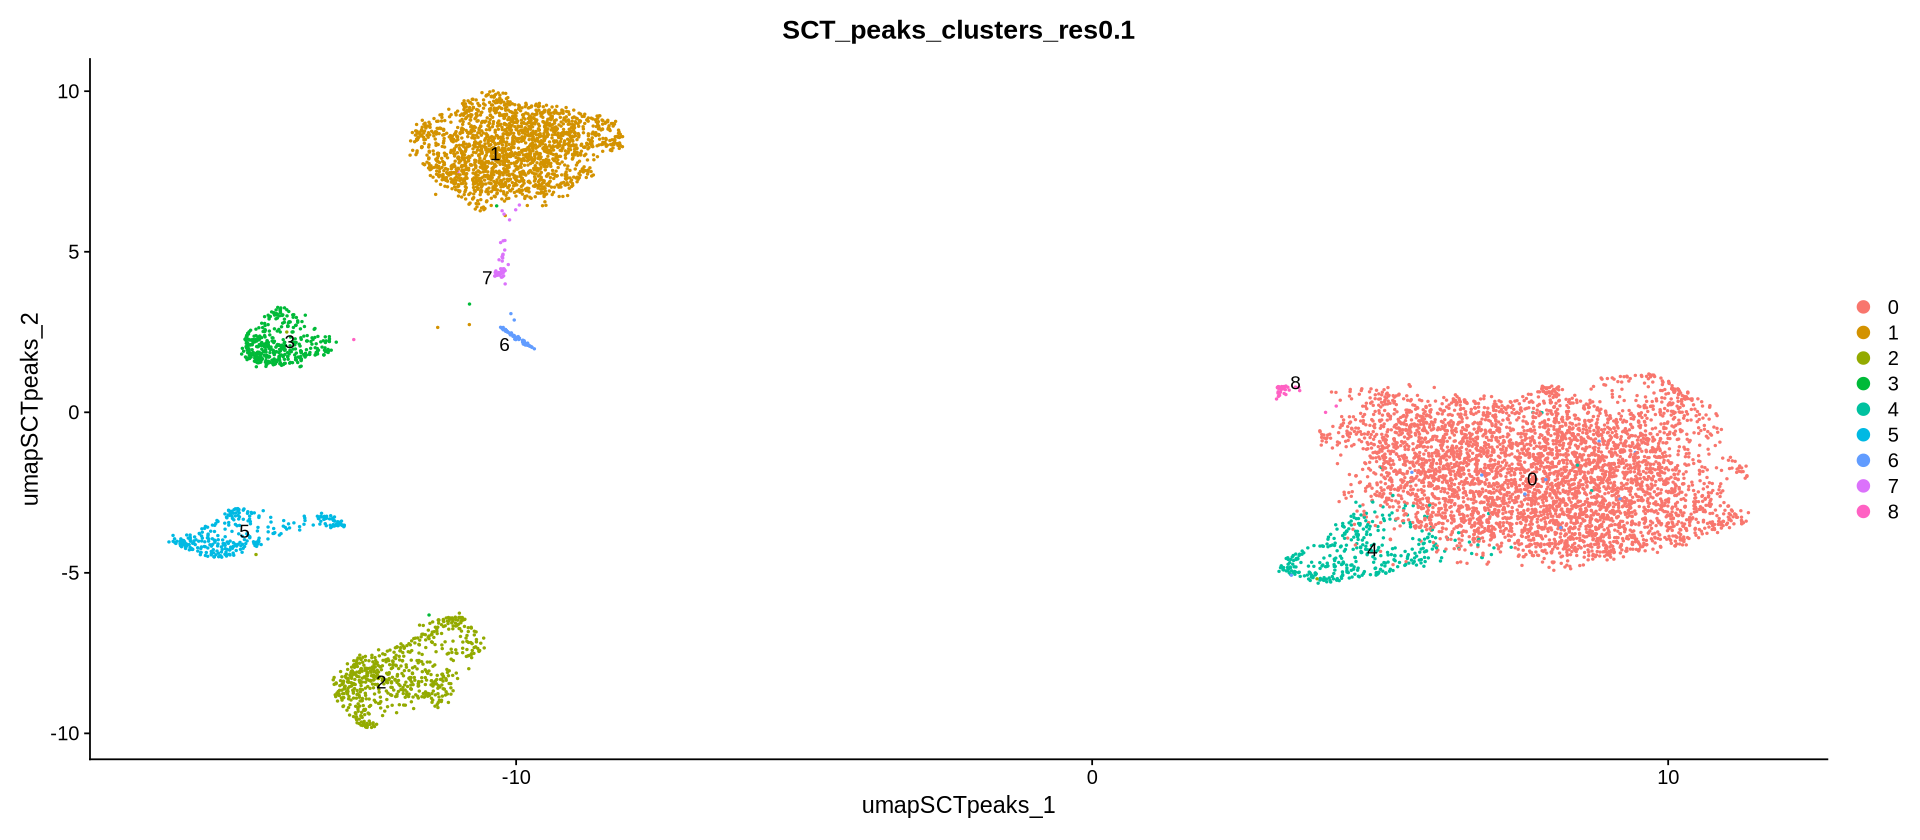

In [60]:
DefaultAssay(heart_cell_atlas) <- "SCT" 
# build a joint neighbor graph using both assays
heart_cell_atlas <- FindMultiModalNeighbors(
  object = heart_cell_atlas,
  reduction.list = list("pca_sct", "lsi"), # on SCT and on peaks
  dims.list = list(1:30, 2:15),
  k.nn = 10,
  knn.graph.name = "wknn_SCT_peaks",
  snn.graph.name = "wsnn_SCT_peaks",
  weighted.nn.name = "weighted.nn.SCT_peaks",
  modality.weight.name = c("SCT.weight","peaks.weight"),
  verbose = TRUE
)

# build a joint UMAP visualization
heart_cell_atlas <- RunUMAP(
  object = heart_cell_atlas,
  nn.name = "weighted.nn.SCT_peaks",
  reduction.name = "umap_SCT_peaks",
  verbose = TRUE
)

# Clustering
heart_cell_atlas <- FindClusters(heart_cell_atlas, resolution = 0.2, verbose=FALSE, graph.name="wsnn_SCT_peaks", cluster.name = "SCT_peaks_clusters_res0.2")
DimPlot(heart_cell_atlas, reduction = "umap_SCT_peaks", group.by = "SCT_peaks_clusters_res0.2", label = TRUE, repel = TRUE)

heart_cell_atlas <- FindClusters(heart_cell_atlas, resolution = 0.1, verbose=FALSE, graph.name="wsnn_SCT_peaks", cluster.name = "SCT_peaks_clusters_res0.1")
DimPlot(heart_cell_atlas, reduction = "umap_SCT_peaks", group.by = "SCT_peaks_clusters_res0.1", label = TRUE, repel = TRUE)

In [61]:
saveRDS(heart_cell_atlas, file = paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called_clustered.rds"), compress = "xz")

In [4]:
sample_to_use <- "HCAHeartST11350194_HCAHeartST11445771"
out_dir <- "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data"
heart_cell_atlas = readRDS(paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called_clustered.rds"))

In [5]:
str(heart_cell_atlas[["RNA"]], max.level = 3)

Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  ..@ layers    :List of 3
  .. ..$ counts    :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. ..$ data      :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. ..$ scale.data: num [1:2000, 1:8358] -0.0146 -0.033 -0.2671 -0.3101 -0.1644 ...
  ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  ..@ features  :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  ..@ default   : int 1
  ..@ assay.orig: chr(0) 
  ..@ meta.data :'data.frame':	32732 obs. of  8 variables:
  .. ..$ vf_vst_counts_mean                 : num [1:32732] 0 0 0 0.00347 0.000239 ...
  .. ..$ vf_vst_counts_variance             : num [1:32732] 0 0 0 0.003458 0.000239 ...
  .. ..$ vf_vst_counts_variance.expected    : num [1:32732] 0 0 0 0.003891 0.000243 ...
  .. ..$ vf_vst_counts_variance.standardized: num [1:32732] 0 0 0 0.889 0.983 ...
  .. ..$ vf_vst_counts_variable             : logi [1:32732] FALSE F

In [19]:
unique(heart_cell_atlas@meta.data["donor"])

,donor
,<chr>
AGGTATTGTCTTTGAC-1,A61


In [1]:
heart_cell_atlas

ERROR: Error: object 'heart_cell_atlas' not found


In [29]:
# heart_cell_atlas[["RNA"]]@layers$data
heart_cell_atlas[["RNA"]]$data

  [[ suppressing 32 column names 'AGGTATTGTCTTTGAC-1', 'ACTTACTTCATTAGTG-1', 'CCTTCAATCAGCATTA-1' ... ]]

  [[ suppressing 32 column names 'AGGTATTGTCTTTGAC-1', 'ACTTACTTCATTAGTG-1', 'CCTTCAATCAGCATTA-1' ... ]]

  [[ suppressing 32 column names 'AGGTATTGTCTTTGAC-1', 'ACTTACTTCATTAGTG-1', 'CCTTCAATCAGCATTA-1' ... ]]



32732 x 8358 sparse Matrix of class "dgCMatrix"
                                                                                     
ENSG00000243485 .         .         .         .         .         .         .        
ENSG00000237613 .         .         .         .         .         .         .        
ENSG00000186092 .         .         .         .         .         .         .        
ENSG00000238009 .         .         .         .         .         .         .        
ENSG00000239945 .         .         .         .         .         .         .        
ENSG00000239906 .         .         .         .         .         .         .        
ENSG00000241599 .         .         .         .         .         .         .        
ENSG00000236601 .         .         .         .         .         .         .        
ENSG00000284733 .         .         .         .         .         .         .        
ENSG00000235146 .         .         .         .         .         .         .        
ENSG00

In [2]:
out_dir <- "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data"
heart_cell_atlas <- readRDS(paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called_clustered.rds"))

In [4]:
heart_cell_atlas <- RenameAssays(
    object = heart_cell_atlas,
    Peaks = "ATAC",
    peaks_macs2 = "peaks"
)

Assays(heart_cell_atlas)

Warning message:
"Key 'peaks_' taken, using 'atac_' instead"
Warning message:
"Key 'peaksmacs2_' taken, using 'peaks_' instead"


[1] "RNA"   "SCT"   "ATAC"  "peaks"

In [6]:
DefaultAssay(heart_cell_atlas) <- "RNA"
heart_cell_atlas

An object of class Seurat 
611578 features across 8358 samples within 4 assays 
Active assay: RNA (32732 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: SCT, ATAC, peaks
 5 dimensional reductions calculated: pca_sct, pca_rna, lsi, umap_RNA_peaks, umap_SCT_peaks

In [9]:

out_dir <- "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data"
saveRDS(heart_cell_atlas, file = paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called_clustered.rds"), compress = "xz")

# NOT EXECUTED BELOW HERE

## FINDING BIOMARKERS for clusters: using RNA_peaks_clusters_res0.1
- by default: identifying positive and negative markers for each cluster, compared to each other cluster
- FindAllMarkers() automates this process for all clusters, but you can also test groups of clusters vs. each other, or against all cells.

FindMarkers(pbmc, ident.1 = 2, min.pct = 0.25)
- min.pct: minimum percentage of feature to be detected at a in either of the two groups of cells that are comp.
- logfc.threshold: requires a feature to be d.e. (on average) by some amount between the two groups. Increasing logfc.threshold speeds up the function, but can miss weaker signals.
- max.cells.per.ident: downsampling each group to parameter (increase speed at cost of accuracy)
- ident.1: label of forground cluster that is looked at
- ident.2: background cluster
    - can either be one number, or multiple: c(... , ...)
    - if parameter is not set, each cluster is compared against all others

In [ ]:
# find markers for every cluster compared to all remaining cells
# report only the positive ones
Idents(healthy_breast) <- "RNA_peaks_clusters_res0.1"
healthy_breast.markers <- FindAllMarkers(healthy_breast, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)

Calculating cluster 0



For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8



In [ ]:
# top 2 markers (highest avg logfc) for each cluster
library(dplyr)
top_2_markers <- healthy_breast.markers %>%
    group_by(cluster) %>%
    slice_max(n = 2, order_by = avg_log2FC)


Attaching package: 'dplyr'


The following object is masked from 'package:glmGamPoi':

    vars


The following objects are masked from 'package:Biostrings':

    collapse, intersect, setdiff, setequal, union


The following object is masked from 'package:XVector':

    slice


The following objects are masked from 'package:ensembldb':

    filter, select


The following object is masked from 'package:AnnotationDbi':

    select


The following object is masked from 'package:Biobase':

    combine


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:GenomicRanges':

    intersect, setdiff, union


The following object is masked from 'package:GenomeInfoDb':

    intersect


The following objects are masked from 'package:IRanges':

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from 'package:S4Vectors':

    first, intersect, rename, setdiff, setequal, union


The

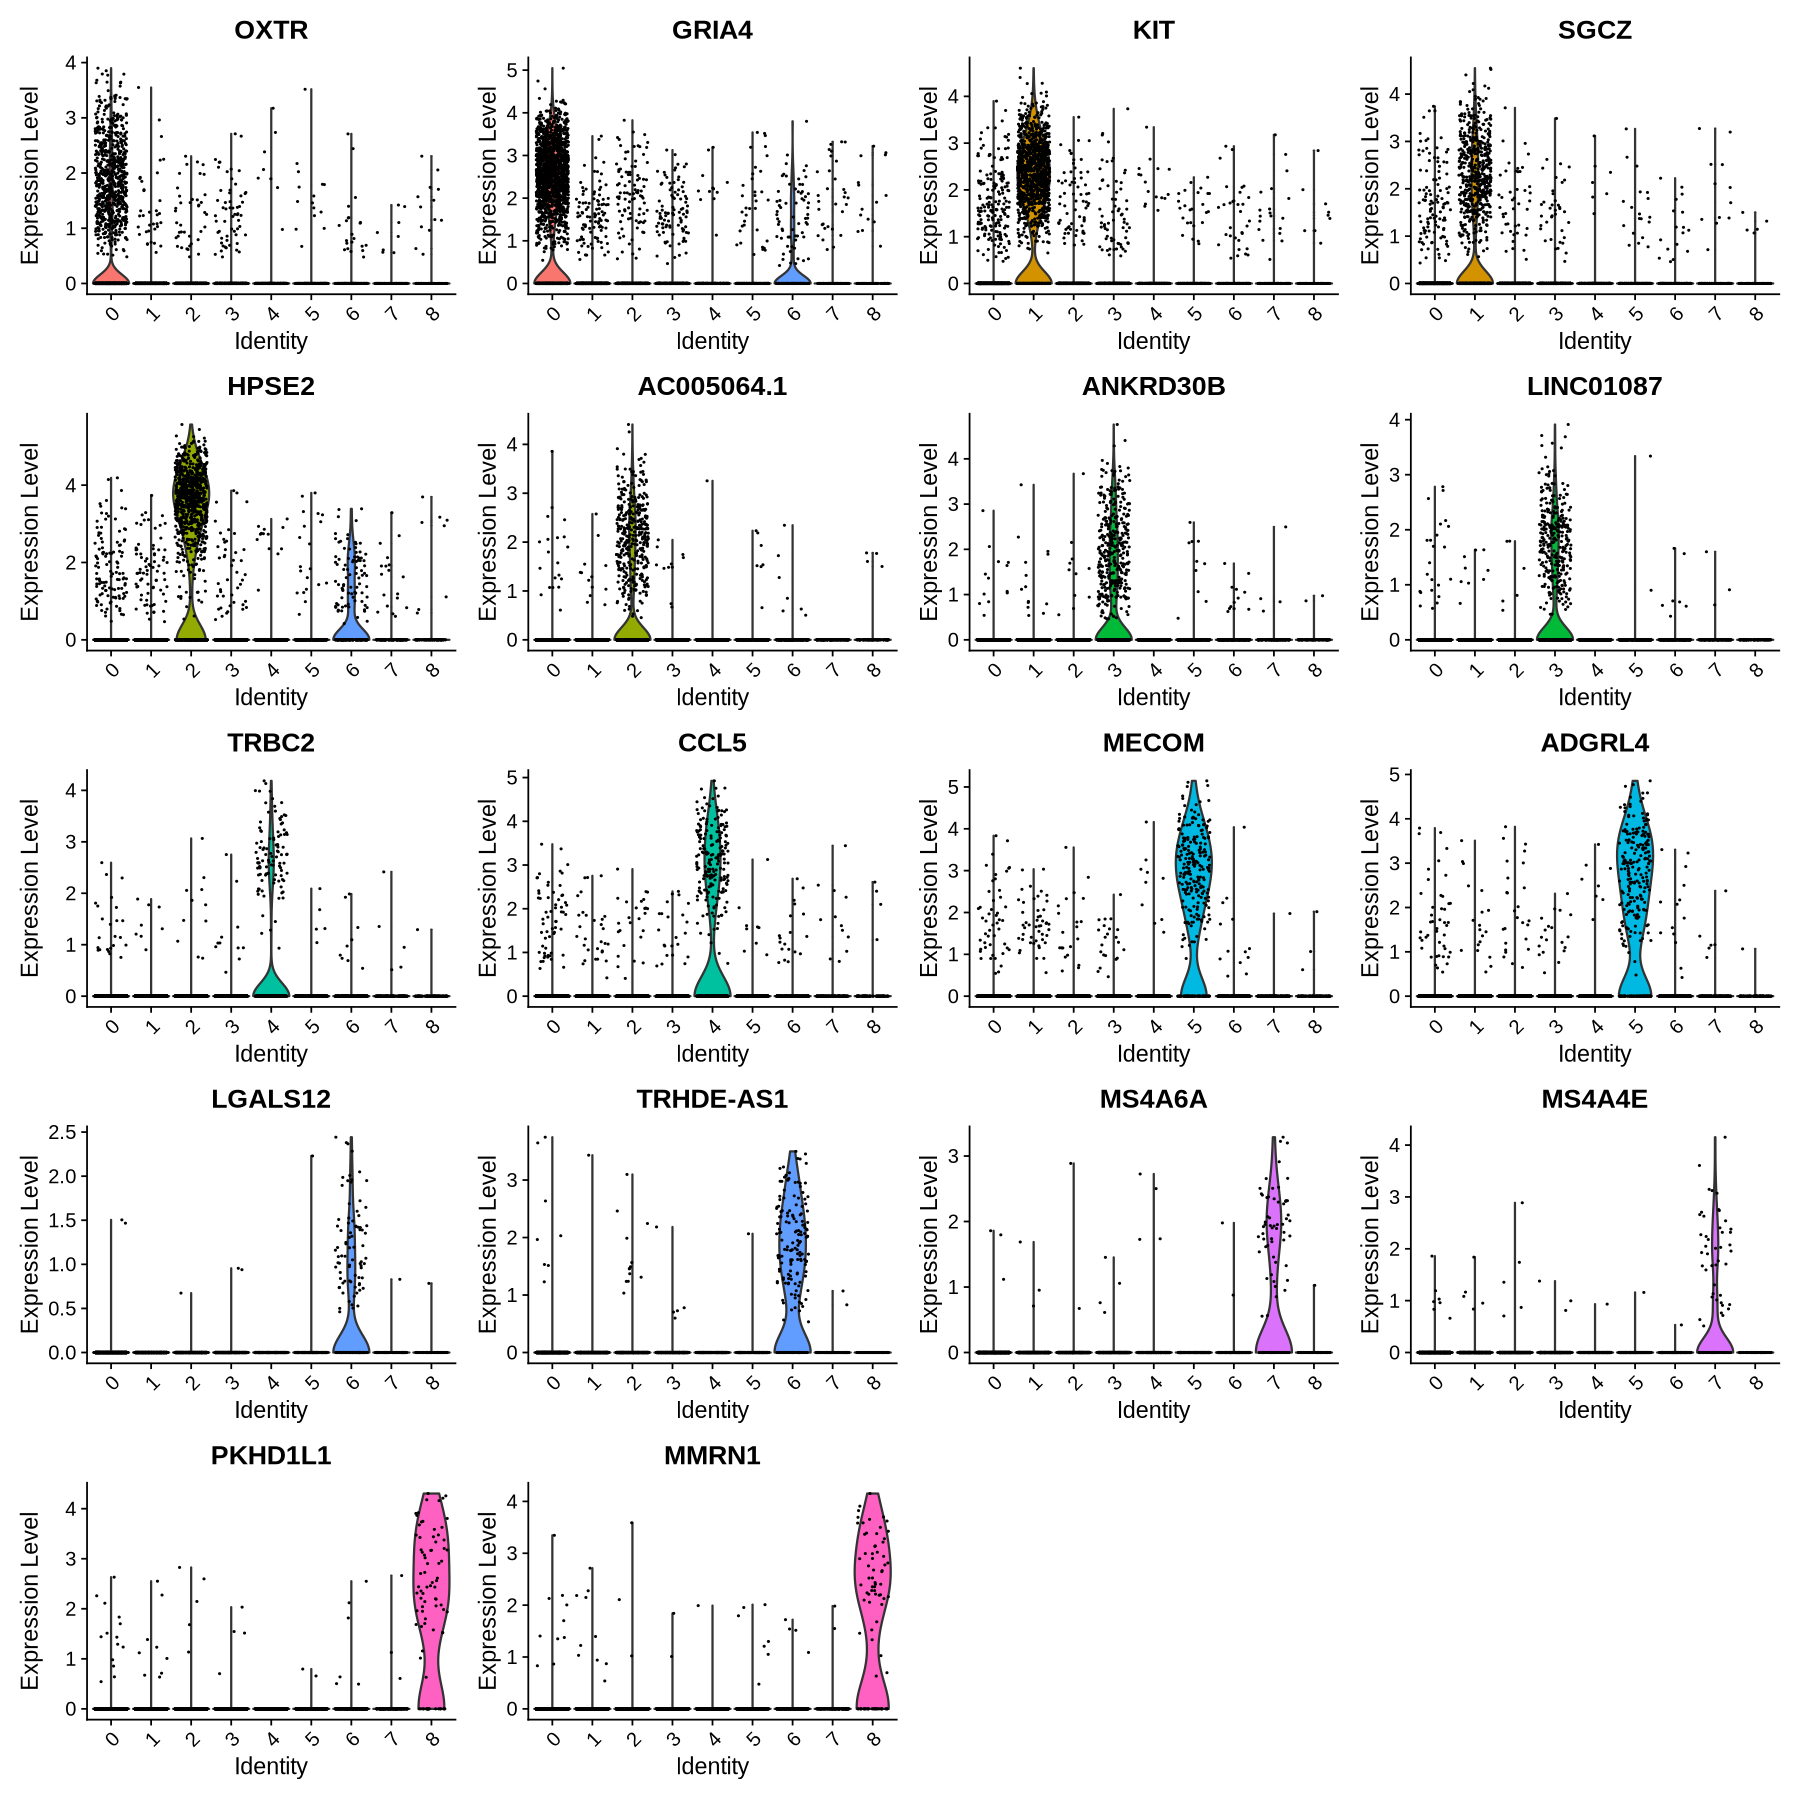

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)
DefaultAssay(healthy_breast) <- "RNA" 
VlnPlot(healthy_breast, features = top_2_markers$gene)

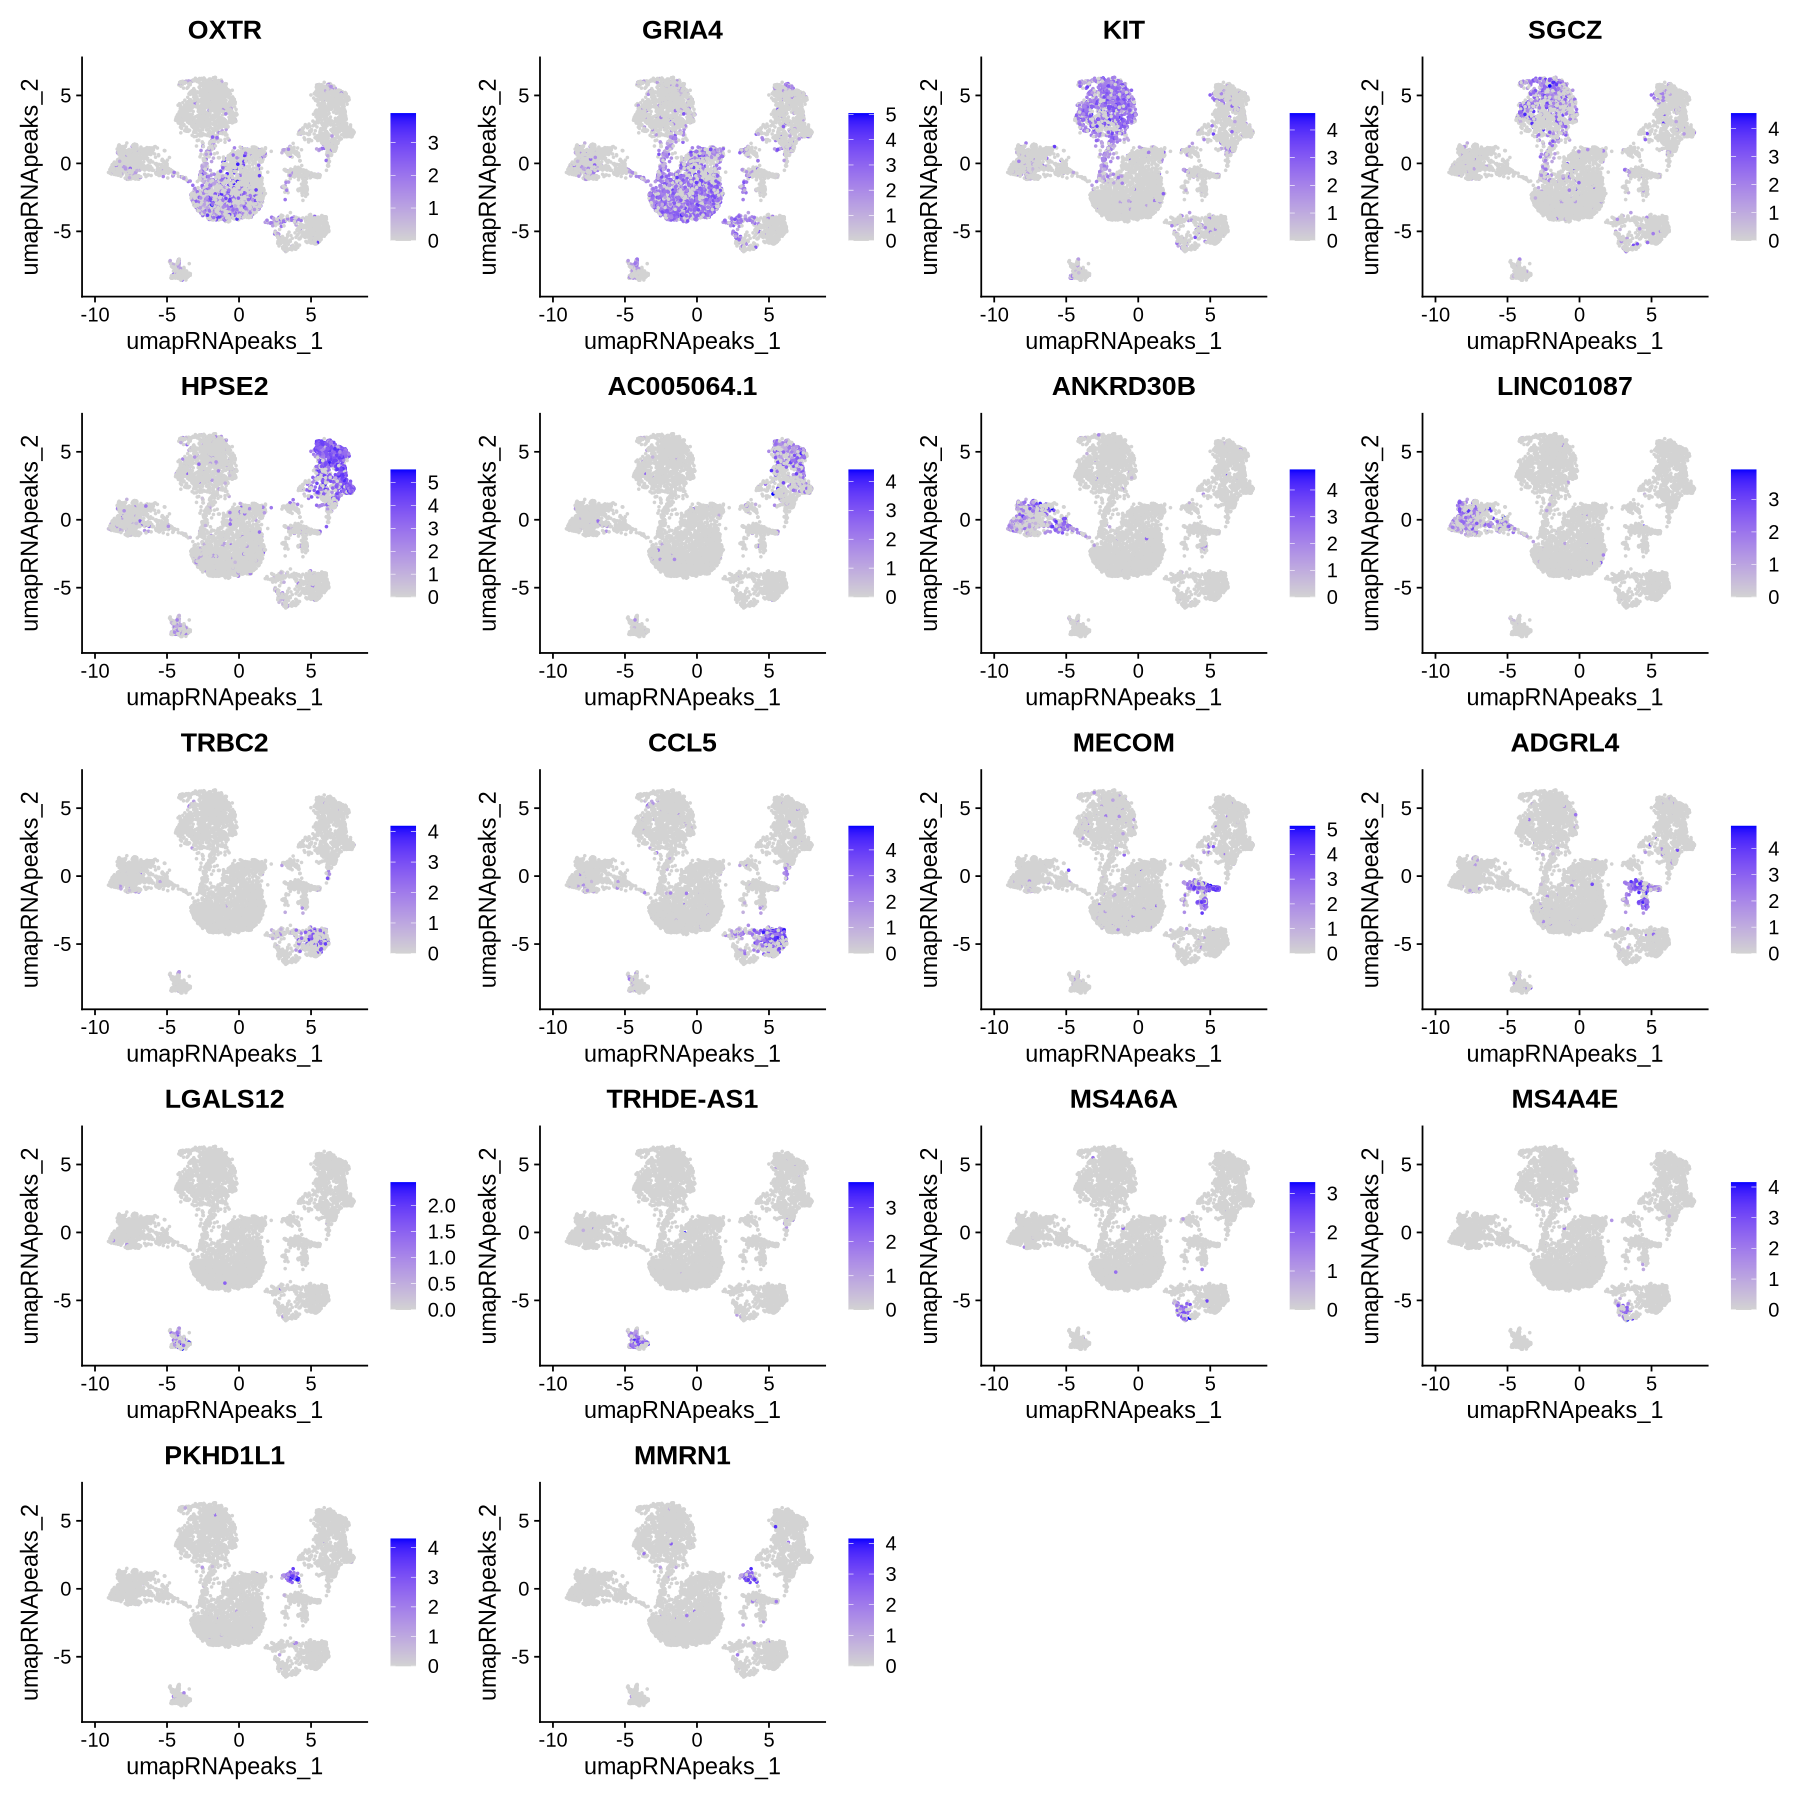

In [ ]:
DefaultAssay(healthy_breast) <- "RNA" 
FeaturePlot(healthy_breast, features = top_2_markers$gene)

# pos and neg markers

In [ ]:
Idents(healthy_breast) <- "RNA_peaks_clusters_res0.1"
all_markers <- FindAllMarkers(healthy_breast, only.pos = FALSE, min.pct = 0.25, logfc.threshold = 0.25)

Calculating cluster 0



Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8



In [ ]:
healthy_breast.markers.pos <- all_markers %>% 
  filter(avg_log2FC > 0) 
healthy_breast.markers.neg <- all_markers %>%
  filter(avg_log2FC < 0)

summary(healthy_breast.markers.pos$avg_log2FC)
summary(healthy_breast.markers.neg$avg_log2FC)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2501  0.5343  0.9461  1.4284  1.8583  9.1661 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-4.2687 -1.7216 -0.9900 -1.2239 -0.5302 -0.2505 

In [ ]:

healthy_breast.markers.neg.top100 <- healthy_breast.markers.neg %>%
  group_by(cluster) %>%
  arrange(desc(abs(avg_log2FC))) %>%
  slice_head(n = 100) %>%
  mutate(annotation = paste("marker.neg.", cluster, sep = ""))

healthy_breast.markers.pos.top100 <- healthy_breast.markers.pos %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC)) %>%
  slice_head(n = 100) %>%
  mutate(annotation = paste("marker.pos.", cluster, sep = ""))

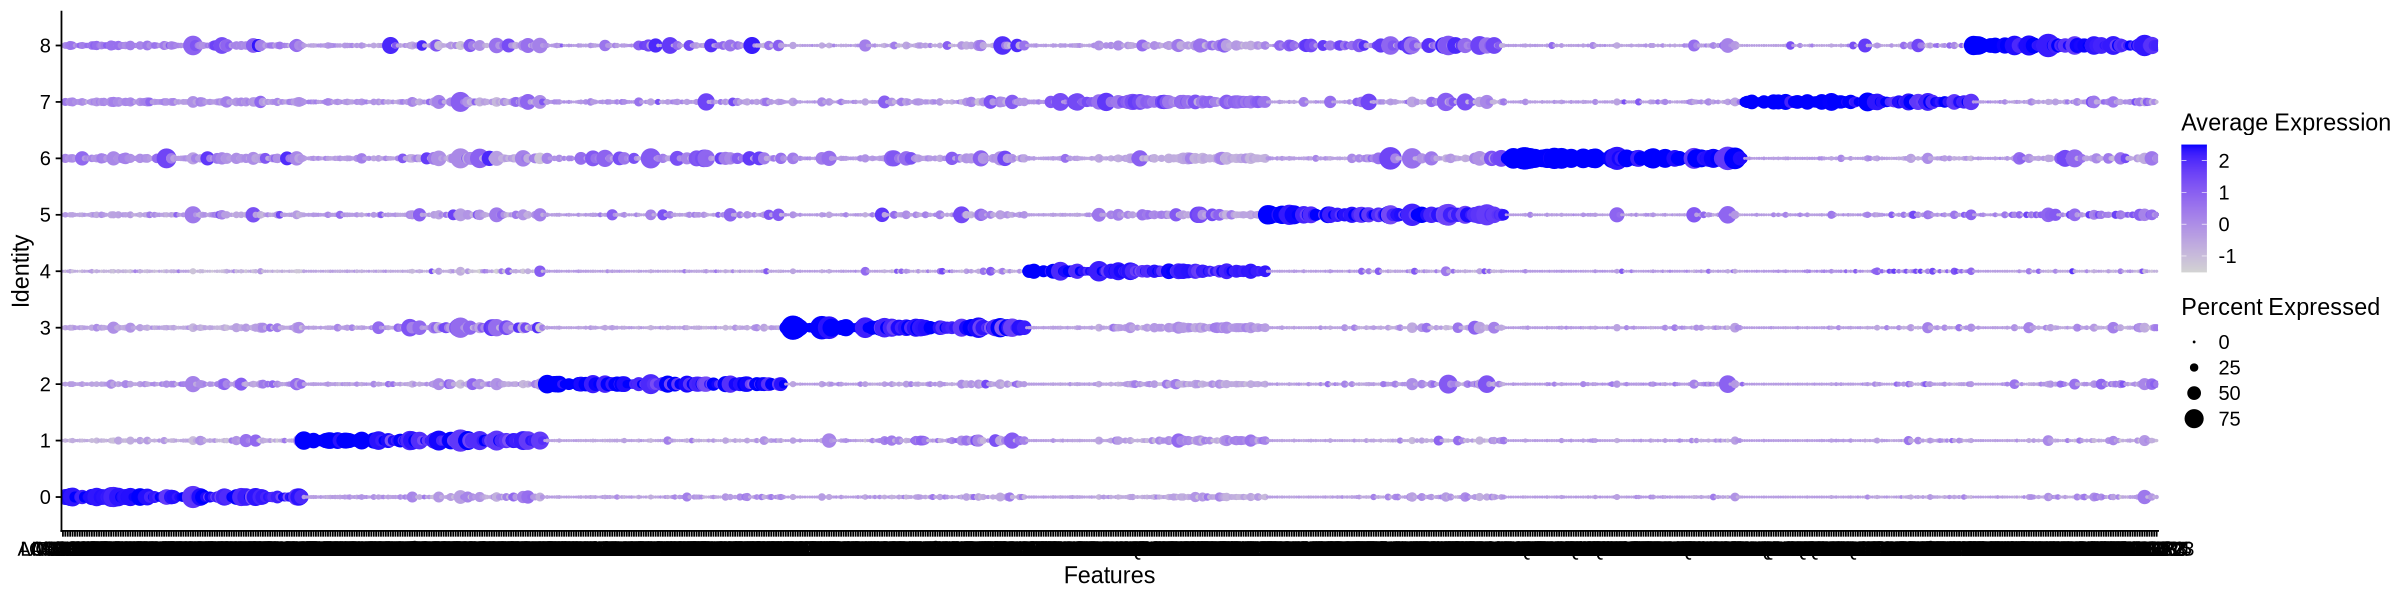

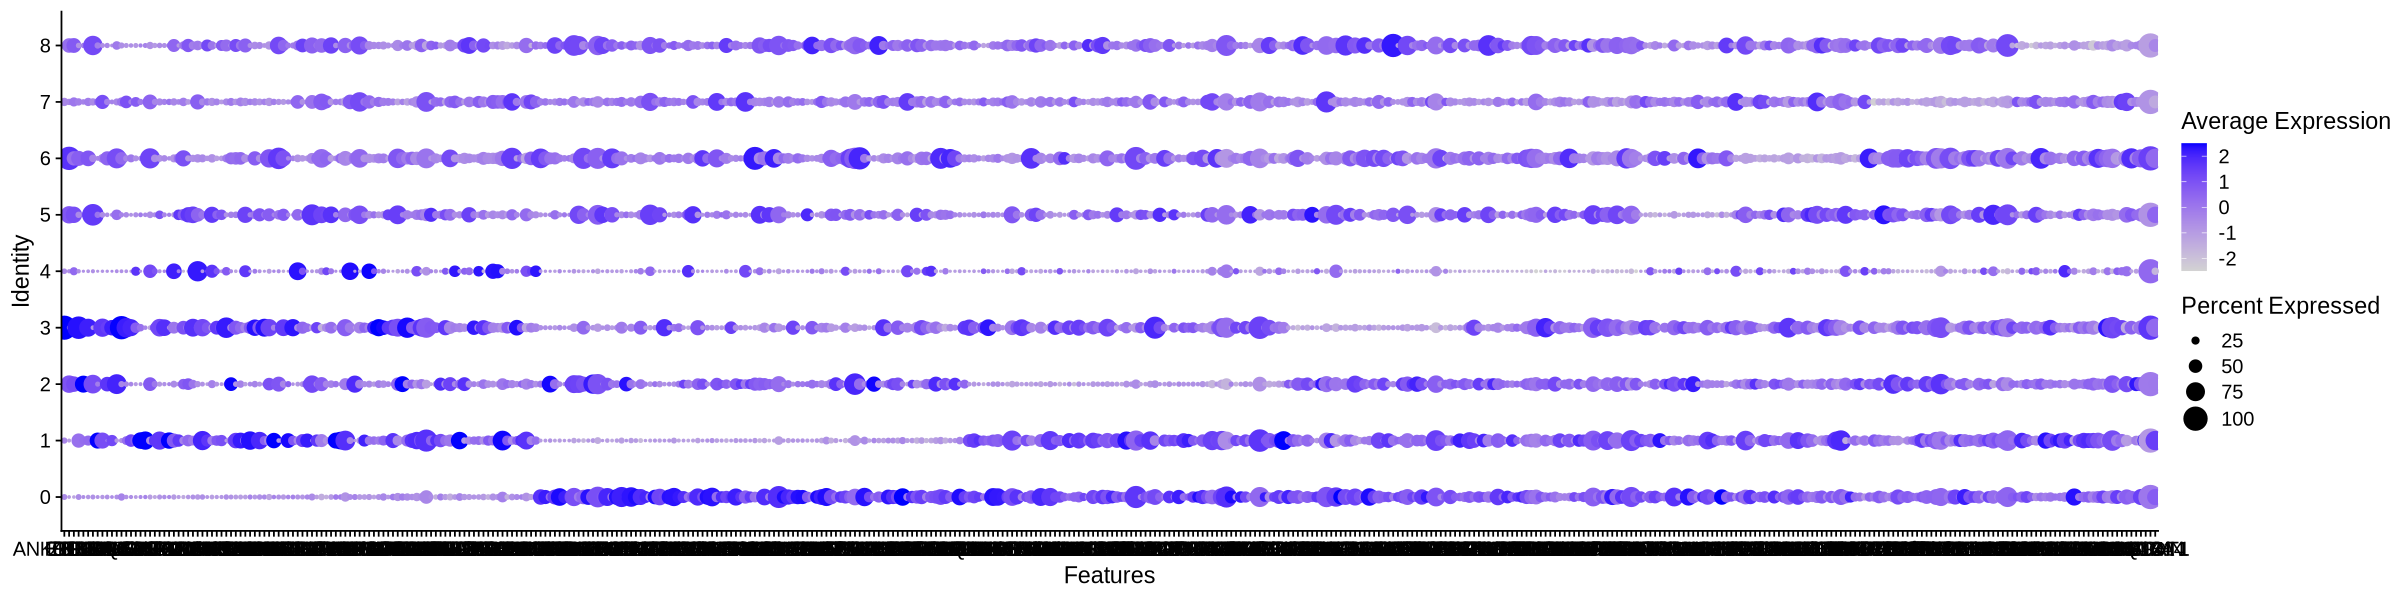

In [ ]:
DotPlot(healthy_breast, 
        features = unique(healthy_breast.markers.pos.top100$gene))
DotPlot(healthy_breast, 
        features = unique(healthy_breast.markers.neg.top100$gene))

## find evenly high/low expressed genes

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   1.216    3.326    6.424   19.952   15.738 2872.767 

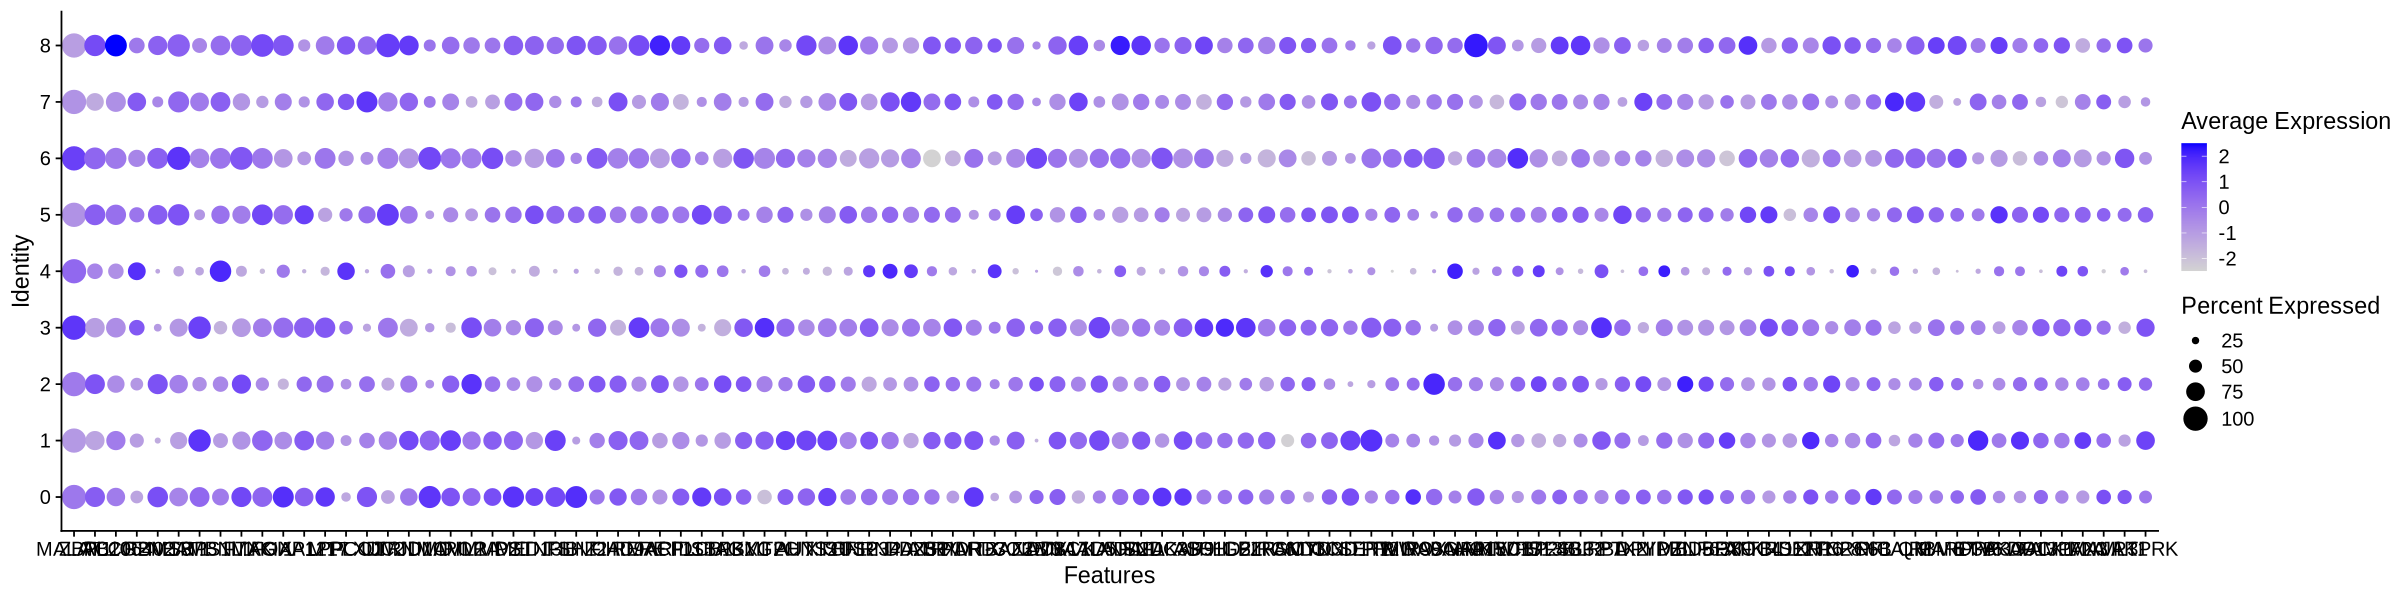

character(0)

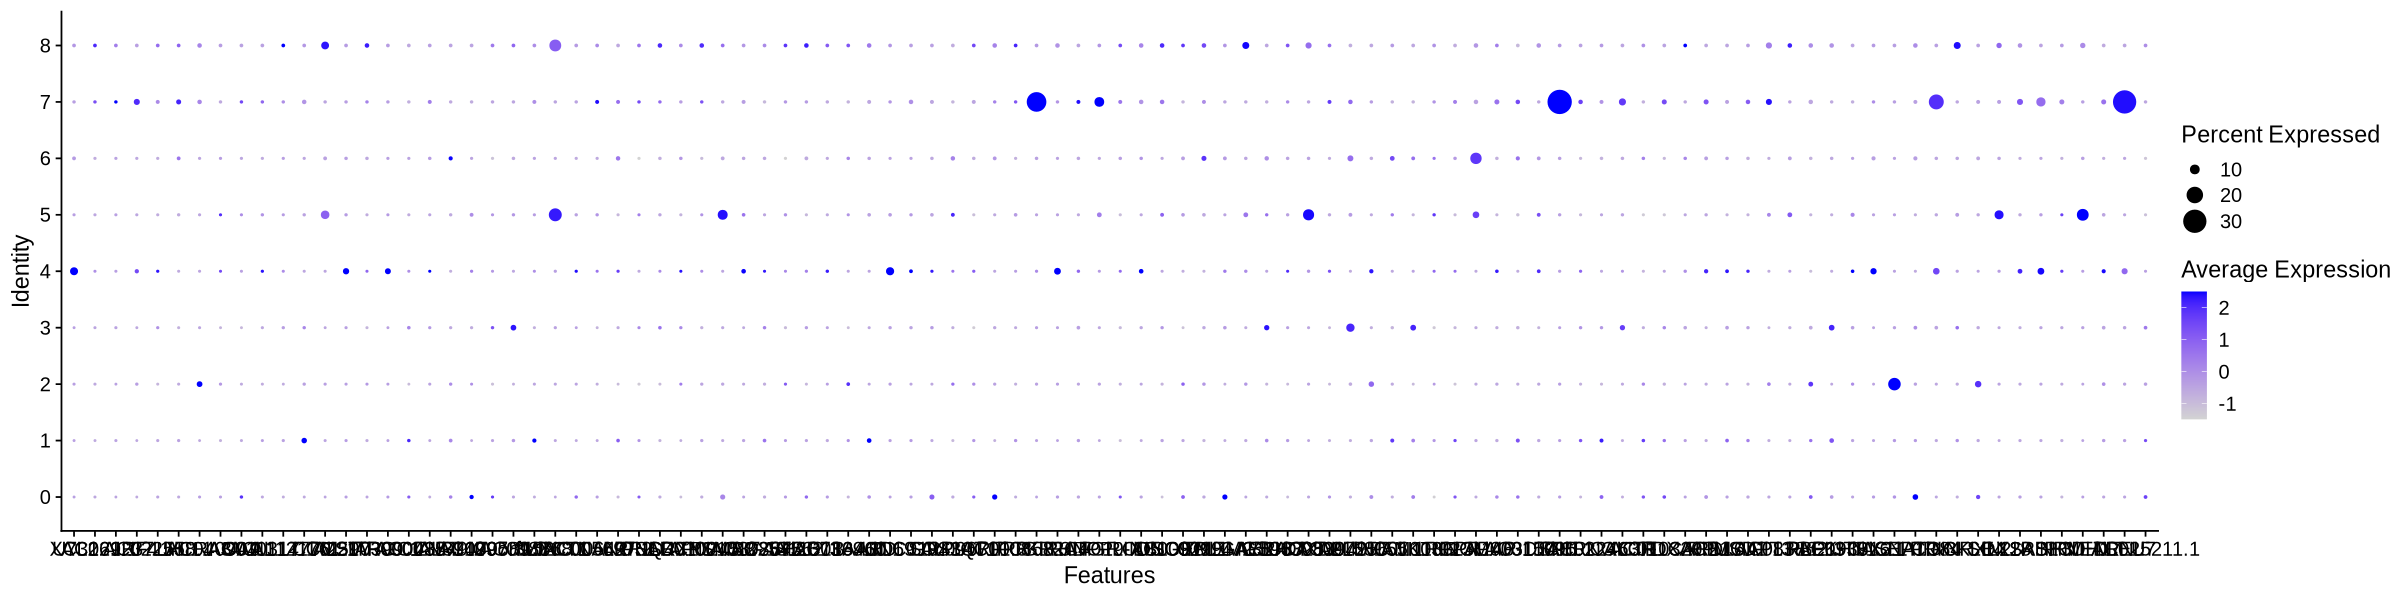

In [ ]:
# Compute the average expression per gene per cluster.
avg_expr_list <- AverageExpression(healthy_breast)
avg_expr_RNA <- avg_expr_list$RNA

# Remove genes that have zero expression in any cluster
has_zero <- apply(avg_expr_RNA, 1, function(gene) any(gene == 0))
expr_nonzero <- avg_expr_RNA[!has_zero, ]
expr_nonzero <- as.matrix(expr_nonzero)

# Compute a ratio of maximum to minimum expression across clusters for each gene (as a measure of expression variability)
expr_ratio <- rowMax(expr_nonzero) / rowMin(expr_nonzero)
summary(expr_ratio)
# expr_nonzero<- expr_nonzero[
#     (rowMax(expr_nonzero)/rowMin(expr_nonzero))] #-> filtered_expr can further be filtered based on this ratio if needed
# summary(expr_ratio)

# overall highly expressed genes:
# Rank genes by their median expression to identify overall highly or lowly expressed ones
gene_medians <- matrixStats::rowMedians(as.matrix(expr_nonzero))
# top 100 highly expressed genes
ranked_high <- order(gene_medians, decreasing = TRUE)
high_genes <- rownames(expr_nonzero)[ranked_high[1:100]]

# top 100 lowly expressed genes
ranked_low <- order(gene_medians)
low_genes <- rownames(expr_nonzero)[ranked_low[1:100]]

# Visualize the expression of these genes using DotPlot
options(repr.plot.width = 20, repr.plot.height = 5)
DotPlot(healthy_breast, 
        features = high_genes)
DotPlot(healthy_breast, 
        features = low_genes)




In [ ]:
intersect(low_genes,high_genes)
# nice, no intersect

character(0)

In [ ]:

n_clusters <- length(unique(Idents(healthy_breast)))

high_expr_overall <- data.frame(
  p_val = NA,
  avg_log2FC = NA,
  pct.1 = NA,
  pct.2 = NA,
  p_val_adj = NA,
  cluster = rep(seq_len(n_clusters) - 1, each = length(high_genes)),
  gene = rep(high_genes, times = n_clusters),
  annotation = "overall_highly_expressed"
)

low_expr_overall <- data.frame(
  p_val = NA,
  avg_log2FC = NA,
  pct.1 = NA,
  pct.2 = NA,
  p_val_adj = NA,
  cluster = rep(seq_len(n_clusters) - 1, each = length(low_genes)),
  gene = rep(low_genes, times = n_clusters),
  annotation = "overall_lowly_expressed"
)

head(high_expr_overall)
head(low_expr_overall)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,annotation
,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<chr>,<chr>
1,NA,NA,NA,NA,NA,0,MALAT1,overall_highly_expressed
2,NA,NA,NA,NA,NA,0,ZBTB20,overall_highly_expressed
3,NA,NA,NA,NA,NA,0,PLCG2,overall_highly_expressed
4,NA,NA,NA,NA,NA,0,AC105402.3,overall_highly_expressed
5,NA,NA,NA,NA,NA,0,RBMS3,overall_highly_expressed
6,NA,NA,NA,NA,NA,0,NEAT1,overall_highly_expressed


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,annotation
,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<chr>,<chr>
1,NA,NA,NA,NA,NA,0,XCL2,overall_lowly_expressed
2,NA,NA,NA,NA,NA,0,U73169.1,overall_lowly_expressed
3,NA,NA,NA,NA,NA,0,AC021237.1,overall_lowly_expressed
4,NA,NA,NA,NA,NA,0,IRF4,overall_lowly_expressed
5,NA,NA,NA,NA,NA,0,AC022558.1,overall_lowly_expressed
6,NA,NA,NA,NA,NA,0,LYL1,overall_lowly_expressed


## put together all markers

In [ ]:

markers.annotated<-rbind(low_expr_overall, 
                         high_expr_overall, 
                         healthy_breast.markers.neg.top100,
                         healthy_breast.markers.pos.top100 )

In [ ]:
healthy_breast@misc$markers.annotated<-markers.annotated

In [ ]:

saveRDS(healthy_breast, "/nfs/home/students/m.back/multiome_data/diverse_ancestry_2024/KTB_pool-4-Ashkenazi_jew/rds_files/healthy_breast_preprocessed.rds")

## OLD: conversion methods to anndata

In [ ]:
library(SeuratDisk)
#dir.create("GSM7821192_2024", showWarnings = FALSE)
SeuratDisk::SaveH5Seurat(
  healthy_breast,
  filename = "GSM7821192_2024/healthy_breast_processed.h5seurat",
  overwrite = TRUE
)

# 2) Convert that file to .h5ad
SeuratDisk::Convert(
  source = "GSM7821192_2024/healthy_breast_processed.h5seurat",
  dest   = "h5ad",
  assay  = "SCT",   # or "RNA" if you prefer RNA as default
  overwrite = TRUE
)

Creating h5Seurat file for version 3.1.5.9900

Adding counts for ATAC

Adding data for ATAC

No variable features found for ATAC

Adding feature-level metadata for ATAC

Writing out ranges for ATAC

Writing out motifs for ATAC

Writing out fragments for ATAC

Writing out seqinfo for ATAC

Writing out annotation for ATAC

Writing out bias for ATAC

Writing out positionEnrichment for ATAC

Writing out links for ATAC

Adding counts for peaks

Adding data for peaks

Adding variable features for peaks

Adding feature-level metadata for peaks

Writing out ranges for peaks

Writing out motifs for peaks

Writing out fragments for peaks

Writing out seqinfo for peaks

Writing out annotation for peaks

Writing out bias for peaks

Writing out positionEnrichment for peaks

Writing out links for peaks

Adding counts for SCT

Adding data for SCT

Adding scale.data for SCT

Adding variable features for SCT

No feature-level metadata found for SCT

Writing out SCTModel.list for SCT

Adding cell embedd

In [ ]:
# https://github.com/cellgeni/sceasy
library(sceasy)
sceasy::convertFormat(healthy_breast, from="seurat", to="anndata",
                       outFile='GSM7821192_2024/healthy_breast_processed.h5ad')

ERROR: Error in library(sceasy): es gibt kein Paket namens 'sceasy'
